# Plantilla: análisis de un sismo con el acelerómetro UdeA y las estaciones del SGC

Este notebook replica, para **cualquier sismo**, todo el análisis que se hizo para el terremoto del Chocó
(2026-08-10, M7.4) en `terremoto_choco_dabeiba.ipynb`. Solo hay que organizar los archivos como explica la
guía (§1), editar **la celda de configuración (§4)** y hacer **Run All**.

Qué hace:

1. **Reconstruye la señal continua del acelerómetro UdeA** a partir de los `.bin` de grabación continua
   (`aceleraciones`) y de los `.bin` de alertas (`eventos`): ordena los archivos por la hora de su nombre,
   rellena los huecos con los eventos que caen en ellos y el resto por interpolación lineal, quita la línea
   base y marca las alertas del detector.
2. **Carga cada estación del SGC con la mejor fuente disponible**: `.mseed` calibrado con el `.anc`, solo
   `.anc`, o solo `.mseed`.
3. Para **cada ventana de tiempo** configurada genera las gráficas del acelerómetro solo, de cada estación
   sola, de ambos superpuestos, y de los **grupos de estaciones juntas** que se definan
   (`juntar_estaciones()` se puede llamar a mano con cualquier combinación).
4. Todo en **g** y **cm/s²**, en **hora UTC** y **hora local**, con el formato de las gráficas oficiales del
   SGC (900×900 px, filas Z/N/E, código de estación, PGA, franjas de alerta).
5. **Animaciones (GIF)**: la traza se dibuja como en un sismógrafo y las franjas "Alerta Detectada"
   aparecen cuando el frente de onda pasa por ellas.

Todo se guarda en `output/<SISMO>/`. La configuración por defecto es la del Chocó, así que el notebook
funciona tal cual como ejemplo.

| Sección | Contenido |
|---|---|
| §1 | Guía: cómo organizar los datos, nombrar estaciones, zonas horarias, ventanas, animaciones |
| §2 | Librerías, constantes e importación de `sismo_utils.py` |
| §3 | Crear las carpetas de un sismo nuevo |
| §4 | **Configuración (la única celda que se edita)** |
| §5 | Verificación de la configuración |
| §6–§11 | Funciones: acelerómetro, SGC y ventanas (en `sismo_utils.py`); gráficas, animaciones y estaciones juntas |
| §12–§16 | Ejecución: acelerómetro, estaciones, comparaciones, estaciones juntas |
| §17 | Resumen: PGA y archivos generados |

## §1 — Guía: cómo preparar los datos de un sismo

### 1.1 Estructura de carpetas (una carpeta por sismo)

```
data/sismos/<sismo>/
├── aceleraciones/   <- .bin de grabación continua del acelerómetro UdeA
├── eventos/         <- .bin de las alertas que disparó el detector
└── sgc/             <- .anc y .mseed del Servicio Geológico Colombiano
output/<sismo>/      <- lo crea este notebook (no poner nada aquí)
```

- `<sismo>` es un nombre corto, sin espacios ni tildes, por ejemplo `choco_2026-08-10`. Es el valor de
  `SISMO` en la configuración (§4) y el nombre de la carpeta de salida.
- Para crear las carpetas vacías: `preparar_carpetas_sismo("<sismo>")` (§3).
- El sismo del Chocó se analizó antes de definir esta estructura: sus archivos siguen en
  `data/aceleraciones/terremoto_choco/`, `data/eventos/terremoto_choco/` y
  `data/Datos_SGC_Terremoto_Choco/`, y la configuración por defecto apunta ahí. No hace falta moverlos.

### 1.2 Datos del acelerómetro UdeA: aceleraciones y eventos

| Carpeta | Nombre del archivo | Qué es |
|---|---|---|
| `aceleraciones/` | `accel_YYYYMMDD_HHMMSS.bin` | grabación continua, un archivo por minuto (60 s a 200 Hz) |
| `eventos/` | `evento_YYYYMMDD_HHMMSS_sNN.bin` | los 4 s que guarda el nodo cuando el detector dispara una alerta; `sNN` es el puntaje del detector |

- Copiar los archivos **tal como salen de la tarjeta SD, sin renombrarlos**: la fecha y hora del nombre es
  la única marca de tiempo absoluta (el contador interno del ESP32 cuenta desde que se encendió).
- La hora del nombre es **hora local de Colombia (UTC−5)**.
- Copiar al menos los minutos que cubren el sismo, con margen antes y después (en el Chocó se usó la hora
  completa). El notebook ordena los archivos por la hora de su nombre.
- Mientras el nodo guarda un evento deja de grabar la señal continua, así que quedan huecos. El notebook
  los rellena con los eventos que caen en el hueco y el resto por interpolación lineal, e informa cuántos
  segundos son interpolados (§12).
- Si el detector no disparó ninguna alerta, `eventos/` puede quedar vacía.

### 1.3 Datos del SGC: archivos `.anc` y `.mseed`

Para cada estación del SGC se ponen en `sgc/` uno o ambos formatos:

- **`.anc`** (texto): `estacion_<municipio>_<idEventoSGC>_<CODIGO>_<LOC>.anc`, por ejemplo
  `estacion_dabeiba_SGC2026pqqmro_DBB_10.anc`. Viene calibrado en cm/s², a 200 Hz y con 510 s de datos,
  pero **no trae la hora de inicio del registro** (solo la hora de origen del sismo). Dejar el nombre como
  viene: el notebook lo encuentra por el final `_<CODIGO>_<LOC>.anc`.
- **`.mseed`** (miniSEED): datos crudos en cuentas del digitalizador, con hora exacta y ~20 min de
  registro. Sirven los dos formatos en que ha llegado: un archivo con todos los canales (`DBB.mseed`,
  `RIO2C.mseed`) o un archivo por canal (`CBOCA_HNE.mseed`, `CBOCA_HNN.mseed`, `CBOCA_HNZ.mseed`). El
  nombre del archivo no importa: el notebook lee todos los `.mseed` de la carpeta y los separa por el código
  de estación que traen adentro.
- De los `.mseed` solo se usan los canales acelerográficos **`HNE`, `HNN`, `HNZ`** (localización `10`). Los
  de banda ancha `HH*` (loc. `00`) y de periodo corto `EH*` (loc. `20`) se ignoran, igual que cualquier
  archivo de otra estación que esté en la carpeta (en el Chocó, `SGCWaveForm.mseed` es de la estación BRJC en
  2020 y no se usa).
- Lo ideal es descargar **los dos formatos de cada estación**: el `.mseed` da la hora exacta y la ventana
  larga, y el `.anc` da la calibración (ver 1.7).

### 1.4 Cómo nombrar las estaciones

Cada estación se declara en `ESTACIONES_SGC` (§4):

| Clave | Qué poner | De dónde sale | Ejemplo |
|---|---|---|---|
| `nombre` | municipio, como se quiere ver en títulos, leyendas y carpetas | a elección | `"Dabeiba"` |
| `codigo` | código de la estación del SGC | línea `CODIGO DE LA ESTACION` del `.anc`, o el `station` del `.mseed` (`CM.DBB.10.HNZ` → `DBB`) | `"DBB"` |
| `red` | código de red | primera parte del identificador del `.mseed` | `"CM"` |
| `loc` | localización de los canales `HN*` | tercera parte del identificador | `"10"` |
| `color` | color suave de la traza en las gráficas de estaciones juntas | a elección | `"#EF9A9A"` |

Claves opcionales: `"fuente"` (`"auto"`, `"mseed"` o `"anc"`, para forzar una fuente), `"inicio_anc_utc"`
(hora real de inicio del `.anc`, si se conoce) y `"escala_cms2_por_cuenta"` (factor de calibración del
`.mseed`, si se conoce y no hay `.anc`).

- El **orden de la lista es el orden de dibujo** en las gráficas de estaciones juntas: el acelerómetro UdeA
  siempre va al fondo y encima las estaciones en ese orden (la última queda al frente).
- El acelerómetro UdeA se identifica como `PAN.PANUDEA01.` (diccionario `ACELEROMETRO`).
- Si no se conoce el código de una estación: abrir su `.anc` (línea 6) o ejecutar
  `print(obspy_read("ruta/al/archivo.mseed"))` después de §2.

### 1.5 Hora local y hora UTC

- Los `.bin` del acelerómetro tienen **hora local** (Colombia, UTC−5) en el nombre; el SGC trabaja en
  **UTC**. Internamente todo se pasa a UTC con `TZ_OFFSET_HORAS = -5`.
- En el Chocó se comprobó así: al pasar la hora local a UTC, las alertas del detector caen justo en la
  llegada de las ondas P y S calculada con la distancia epicentral.
- **Cada gráfica y cada animación se guarda dos veces**: `_UTC` (hora oficial / internacional) y `_LOCAL`
  (hora de Colombia). Se controla con `ZONAS` en la configuración.

### 1.6 Ventanas de tiempo del acelerómetro

`VENTANAS` es una lista: cada ventana genera su propio juego de gráficas y animaciones en
`output/<sismo>/<nombre de la ventana>/`. La ventana recorta **todas** las trazas (acelerómetro y SGC).

| `modo` | Qué intervalo toma | Parámetros |
|---|---|---|
| `"hora_completa"` | toda la señal reconstruida del acelerómetro | — |
| `"estacion"` | el registro de la estación (en estaciones juntas: el tramo común a todas las elegidas) | — |
| `"primera_alerta"` | desde la primera alerta del detector hasta el fin del registro de la estación | — |
| `"relativa_origen"` | alrededor de la hora de origen del sismo | `antes_s`, `despues_s` |
| `"manual"` | un intervalo cualquiera | `inicio`, `fin` (`"YYYY-MM-DD HH:MM:SS"`) y `zona` (`"LOCAL"` o `"UTC"`) |

Las gráficas del acelerómetro sobre la hora completa siempre se generan (`output/<sismo>/acelerometro/`).

### 1.7 Qué fuente usa cada estación

| Archivos en `sgc/` | Qué se grafica | Unidades | Hora de inicio |
|---|---|---|---|
| `.mseed` + `.anc` | el `.mseed`, calibrado contra el `.anc` por correlación cruzada | cm/s² y g | la del `.mseed` (exacta); de paso da la hora real de inicio del `.anc` |
| solo `.anc` | el `.anc` | cm/s² y g | estimada: origen + `ANC_INICIO_OFFSET_S` (−30 s, lo medido en las 3 estaciones del Chocó), o `inicio_anc_utc` si se conoce |
| solo `.mseed` | el `.mseed` en cuentas (o con `escala_cms2_por_cuenta`) | cuentas | la del `.mseed` |

- Con solo `.mseed` y sin factor de escala **no se inventa una calibración**: la estación se grafica en
  cuentas y su comparación con el acelerómetro se hace **normalizada** (cada traza dividida por su
  desviación estándar, σ), que permite comparar forma y tiempos de llegada pero no amplitudes.
- La calibración imprime el R² de cada canal (en el Chocó > 0.99 en los 9 canales). Un R² bajo indica que
  el `.anc` y el `.mseed` no son de la misma estación o del mismo sismo.

### 1.8 Animaciones

- La traza se revela de izquierda a derecha como en un sismógrafo (todas las trazas avanzan con el mismo
  reloj) y cada franja ámbar "Alerta Detectada" aparece y crece cuando el frente de onda llega a ella.
- Se generan para: el acelerómetro solo (hora completa y cada ventana), cada comparación acelerómetro vs.
  estación y cada grupo de estaciones juntas — en cada unidad y cada zona horaria.
- Tardan unos **25 segundos por GIF**; con la configuración del Chocó (44 GIF) el notebook completo tarda
  unos **20 minutos**. Para una corrida rápida (solo gráficas estáticas): `GENERAR_ANIMACIONES = False`.
  `N_FRAMES` y `FPS` controlan la cantidad de cuadros y la velocidad.

### 1.9 Archivos de salida

```
output/<sismo>/
├── acelerometro/          acelerometro_hora_completa_{g,cms2}_{UTC,LOCAL}.{png,gif}
└── <ventana>/
    ├── acelerometro/      acelerometro_<ventana>_{g,cms2}_{UTC,LOCAL}.{png,gif}
    ├── <Estacion>/        <municipio>_<CODIGO>_<LOC>_{propia,sgc,junta}_{g,cms2}_{UTC,LOCAL}.png
    │                      <municipio>_<CODIGO>_<LOC>_junta_{g,cms2}_{UTC,LOCAL}.gif
    └── juntas_<grupo>/    juntas_<grupo>_{g,cms2}_{UTC,LOCAL}.{png,gif}
```

- `propia` = solo el acelerómetro UdeA, `sgc` = solo la estación, `junta` = ambos superpuestos (UdeA en
  negro, SGC en rojo). Estaciones sin calibrar: `_sgc_cuentas` y `_junta_norm`.
- En pantalla el notebook muestra solo la primera zona horaria de cada gráfica; todas quedan en disco.

### 1.10 Checklist para un sismo nuevo

1. Crear las carpetas: `preparar_carpetas_sismo("<sismo>")` (§3).
2. Copiar los `.bin` en `aceleraciones/` y `eventos/`.
3. Descargar del SGC el `.anc` y el `.mseed` de cada estación y copiarlos en `sgc/`.
4. En §4: cambiar `SISMO`, **borrar las 3 líneas de rutas del Chocó**, llenar `ESTACIONES_SGC`,
   `TITULO_UBICACION` (o `None`), `VENTANAS` y `GRUPOS_ESTACIONES`.
5. Ejecutar hasta §5: debe mostrar cuántos archivos encontró en cada carpeta, sin errores.
6. Run All. Revisar en §13 la fuente y el R² de cada estación, y en §17 el resumen de PGA y archivos.

### 1.11 Problemas conocidos

- Las tildes del `.anc` vienen como `?` (`San Jos? del Palmar - Choc?`): `TITULO_UBICACION` permite escribir
  el lugar bien.
- La línea base del acelerómetro se toma de los primeros `BASELINE_S` segundos: si el sismo empieza ahí,
  copiar más minutos anteriores al sismo.
- Los `.bin` sin el patrón `YYYYMMDD_HHMMSS` en el nombre se ignoran (con aviso).
- Si en §13 una estación aparece como "omitida", el mensaje dice qué archivo falta.

## §2 — Librerías y constantes

Constantes del sensor y de estilo: no dependen del sismo, no hace falta cambiarlas.

Las funciones que comparten los notebooks del sismo (lectura del acelerómetro y del SGC, ventanas de tiempo y piezas
de las gráficas) y las constantes del sensor están en **`sismo_utils.py`**, en la misma carpeta que este notebook.
Si se edita ese archivo, hay que reiniciar el kernel para que se vuelva a importar.

In [1]:
import pathlib

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Patch

# Funciones y constantes comunes a los notebooks del sismo (sensor, componentes, estilo SGC): ver sismo_utils.py
from sismo_utils import (
    G_TO_CMS2, LABELS, CANAL_POR_COMP, ORDEN_FILAS, BANDA_SGC,
    COLOR_ACEL, COLOR_SGC, COLOR_ALERTA, FIGSIZE, DPI,
    slug, nombre_ventana, unir_nombres, zonas_horarias, verificar_configuracion,
    discover_bins, reconstruct_full_hour, imprimir_reconstruccion,
    leer_mseed_carpeta, cargar_estaciones, datos_evento, buscar_estacion,
    resolver_ventana, recortar, convertir,
    alertas_en_rango, encabezado, casilla_ids, mostrar_o_cerrar,
)

_ETIQUETA_UNIDAD = {"g": "g", "cm/s²": "cm/s²", "cuentas": "cuentas", "σ": "σ (normalizado)"}
_SUFIJO_UNIDAD   = {"g": "g", "cm/s²": "cms2", "cuentas": "cuentas", "σ": "norm"}

print("Librerías y constantes cargadas.")

Librerías y constantes cargadas.


## §3 — Crear las carpetas de un sismo nuevo

Descomentar la última línea, poner el nombre del sismo y ejecutar la celda una vez. Crea
`data/sismos/<sismo>/aceleraciones`, `eventos` y `sgc` (si no existen) y dice qué va en cada una.

In [2]:
def preparar_carpetas_sismo(sismo, base="data/sismos"):
    """Crea data/sismos/<sismo>/{aceleraciones,eventos,sgc} y dice qué archivos van en cada una."""
    raiz = pathlib.Path(base) / sismo
    contenido = {
        "aceleraciones": "accel_YYYYMMDD_HHMMSS.bin  (grabación continua, tal como sale de la SD)",
        "eventos":       "evento_YYYYMMDD_HHMMSS_sNN.bin  (alertas del detector)",
        "sgc":           ".anc y .mseed de cada estación del SGC",
    }
    for sub, que in contenido.items():
        carpeta = raiz / sub
        carpeta.mkdir(parents=True, exist_ok=True)
        print(f"  {carpeta}/  <- {que}")
    print(f'En la configuración (§4): SISMO = "{sismo}"')
    return raiz


# preparar_carpetas_sismo("nombre_del_sismo")

## §4 — Configuración

> **La única celda que hay que editar para analizar otro sismo.** Ver la guía (§1).

In [3]:
# -- 1) Sismo -------------------------------------------------------------------------
SISMO = "terremoto_choco"          # nombre de la carpeta de datos y de la carpeta de salida

# -- 2) Carpetas de entrada (estructura recomendada, §1.1) --------------------------------
DIR_SISMO   = pathlib.Path("data/sismos") / SISMO
DIR_ACEL    = DIR_SISMO / "aceleraciones"
DIR_EVENTOS = DIR_SISMO / "eventos"
DIR_SGC     = DIR_SISMO / "sgc"
# El Chocó está en la estructura antigua. PARA UN SISMO NUEVO, BORRAR ESTAS 3 LÍNEAS:
DIR_ACEL    = pathlib.Path("data/aceleraciones/terremoto_choco")
DIR_EVENTOS = pathlib.Path("data/eventos/terremoto_choco")
DIR_SGC     = pathlib.Path("data/Datos_SGC_Terremoto_Choco")

# -- 3) Carpeta de salida --------------------------------------------------------------------
DIR_SALIDA = pathlib.Path("output") / SISMO

# -- 4) Acelerómetro UdeA ----------------------------------------------------------------------
ACELEROMETRO = {
    "nombre":  "Acelerógrafo PANUdeA (Medellín)",   # en los títulos
    "leyenda": "Acelerógrafo PANUdeA",              # en las leyendas
    "red": "PAN", "codigo": "PANUDEA01", "loc": "",
}

# -- 5) Estaciones del SGC (§1.4). Orden = orden de dibujo en las gráficas de estaciones juntas --
ESTACIONES_SGC = [
    {"nombre": "Riosucio", "codigo": "RIO2C", "red": "CM", "loc": "10", "color": "#A5D6A7"},
    {"nombre": "Pereira",  "codigo": "CBOCA", "red": "CM", "loc": "10", "color": "#90CAF9"},
    {"nombre": "Dabeiba",  "codigo": "DBB",   "red": "CM", "loc": "10", "color": "#EF9A9A"},
]
# Claves opcionales por estación: "fuente": "auto" | "mseed" | "anc",
#                                 "inicio_anc_utc": "YYYY-MM-DD HH:MM:SS",
#                                 "escala_cms2_por_cuenta": 2.36e-4

# -- 6) Datos del evento (None = tomarlos de la cabecera del .anc) ----------------------------
TITULO_UBICACION = "San José del Palmar - Chocó"   # el .anc trae las tildes como "?"
MAGNITUD   = None
ORIGEN_UTC = None                                  # p. ej. "2026-08-10 12:34:27" (obligatorio si no hay .anc)

# -- 7) Zonas horarias y unidades ---------------------------------------------------------
TZ_OFFSET_HORAS     = -5          # hora local de Colombia = UTC-5
ETIQUETA_ZONA_LOCAL = "COT"
ZONAS    = ["UTC", "LOCAL"]
UNIDADES = ["g", "cm/s²"]

# -- 8) Parámetros de procesamiento ----------------------------------------------------------
ANC_INICIO_OFFSET_S = -30   # inicio estimado del .anc respecto al origen, si no hay .mseed (§1.7)
BASELINE_S          = 20    # segundos iniciales (tranquilos) para quitar la línea base del acelerómetro

# -- 9) Ventanas de tiempo (§1.6): cada una genera su propio juego de gráficas y animaciones ----
VENTANAS = [
    {"nombre": "registro_sgc",         "modo": "estacion"},
    {"nombre": "desde_primera_alerta", "modo": "primera_alerta"},
    # {"nombre": "sismo",  "modo": "relativa_origen", "antes_s": 60, "despues_s": 300},
    # {"nombre": "manual", "modo": "manual", "inicio": "2026-08-10 07:34:00", "fin": "2026-08-10 07:40:00", "zona": "LOCAL"},
    # {"nombre": "hora",   "modo": "hora_completa"},
]

# -- 10) Grupos de estaciones juntas (UdeA al fondo + las estaciones del grupo, en ese orden) --
GRUPOS_ESTACIONES = {
    "todas": ["Riosucio", "Pereira", "Dabeiba"],
    # "cercanas": ["Riosucio", "Pereira"],
}

# -- 11) Animaciones (§1.8) -------------------------------------------------------------------
GENERAR_ANIMACIONES = True        # False = solo gráficas estáticas (corrida rápida)
N_FRAMES = 50
FPS      = 10

## §5 — Verificación de la configuración

Revisa que existan las carpetas, cuenta los archivos y valida ventanas, grupos, zonas y unidades antes de
procesar nada.

In [4]:
ID_ACEL = f"{ACELEROMETRO['red']}.{ACELEROMETRO['codigo']}.{ACELEROMETRO['loc']}"
PROBLEMAS = []      # avisos que se acumulan durante la ejecución y se listan en §17

print(f"Sismo: {SISMO}")
_errores = verificar_configuracion(DIR_ACEL, DIR_EVENTOS, DIR_SGC, ESTACIONES_SGC, GRUPOS_ESTACIONES, VENTANAS,
                                   ZONAS, UNIDADES, avisos=PROBLEMAS)
if _errores:
    raise ValueError("Revisar la configuración (§4):\n  - " + "\n  - ".join(_errores))

_ZONAS_HORARIAS = zonas_horarias(ZONAS, TZ_OFFSET_HORAS, ETIQUETA_ZONA_LOCAL)
DIR_SALIDA.mkdir(parents=True, exist_ok=True)
print(f"Salidas en      : {DIR_SALIDA}")
print(f"Estaciones      : {[e['nombre'] for e in ESTACIONES_SGC]}")
print(f"Zonas / unidades: {[z[0] for z in _ZONAS_HORARIAS]}  /  {UNIDADES}")
print(f"Ventanas        : {[nombre_ventana(v) for v in VENTANAS]}")
print(f"Grupos juntos   : {list(GRUPOS_ESTACIONES)}")
print(f"Animaciones     : {'sí (' + str(N_FRAMES) + ' cuadros a ' + str(FPS) + ' fps)' if GENERAR_ANIMACIONES else 'no'}")

Sismo: terremoto_choco
  aceleraciones:  58 archivo(s) *.bin    en data\aceleraciones\terremoto_choco
  eventos      :   6 archivo(s) *.bin    en data\eventos\terremoto_choco
  SGC .anc     :   3 archivo(s) *.anc    en data\Datos_SGC_Terremoto_Choco
  SGC .mseed   :   6 archivo(s) *.mseed  en data\Datos_SGC_Terremoto_Choco
Salidas en      : output\terremoto_choco
Estaciones      : ['Riosucio', 'Pereira', 'Dabeiba']
Zonas / unidades: ['UTC', 'Local (COT, UTC-5)']  /  ['g', 'cm/s²']
Ventanas        : ['registro_sgc', 'desde_primera_alerta']
Grupos juntos   : ['todas']
Animaciones     : sí (50 cuadros a 10 fps)


## §6 — Funciones: acelerómetro UdeA

Están en `sismo_utils.py` (se importan en §2), el mismo módulo que usan `plantilla_analisis_sismo.ipynb` y `plantilla_espectros_sismo.ipynb`:

- `parse_bin()`: lee un `.bin` del ESP32 (cabecera `MAGIC/VERSION/SAMPLE_RATE(+lat/lon)` + muestras de 10
  bytes `timestamp_ms, ax, ay, az`; `ax`→EW, `ay`→NS, `az`→VER, 1 LSB = 3.9 mg).
- `reconstruct_full_hour()`: une la grabación continua en una grilla UTC a 200 Hz, rellena huecos con los
  eventos y el resto por interpolación lineal, quita la línea base (`BASELINE_S`) y devuelve las ventanas
  de alerta ordenadas por hora.
- `imprimir_reconstruccion()`: el resumen de la reconstrucción que se muestra en §12.

## §7 — Funciones: estaciones del SGC

Están en `sismo_utils.py` (se importan en §2), el mismo módulo que usan `plantilla_analisis_sismo.ipynb` y `plantilla_espectros_sismo.ipynb`:

- `parse_anc()`: lee un `.anc` (19 líneas de cabecera `clave: valor` + encabezado de columnas + datos en
  cm/s²) y reordena las columnas a `[EW, NS, VER]`.
- `leer_mseed_carpeta()`: lee **todos** los `.mseed` de la carpeta en un solo `Stream` y une los segmentos
  (sirve para un archivo por estación o un archivo por canal).
- `calibrar_canal_mseed()`: factor cuentas → cm/s² de un canal `.mseed` por correlación cruzada contra el
  mismo canal del `.anc`; de paso da la hora real de inicio del `.anc` (usa solo el tramo que se solapa).
- `cargar_estacion()`: aplica las reglas de §1.7 y devuelve la estación en un formato uniforme.
- `cargar_estaciones()` / `datos_evento()`: cargan todas las estaciones de `ESTACIONES_SGC` y toman del `.anc`
  los datos del evento que no estén en la configuración (§13).

## §8 — Funciones: ventanas de tiempo y series para graficar

- `resolver_ventana()` (en `sismo_utils.py`, igual que `recortar()` y `convertir()`) convierte una ventana de `VENTANAS` (§1.6) en `(inicio, fin)` UTC.
- `serie_acelerometro()` / `serie_estacion()` preparan las trazas recortadas a la ventana y en la unidad
  pedida (`"g"`, `"cm/s²"`, `"cuentas"` o `"σ"` normalizado) en el formato que usan las gráficas.

In [7]:
def normalizar_std(sig):
    s = np.std(sig)
    return sig / s if s > 0 else sig


def _serie(t, datos, unidad_origen, unidad_destino, id_nslc, nombre, color, t0=None, t1=None):
    """{comp: [(t, señal, id, nombre_leyenda, color)]} recortada a [t0, t1]; None si queda vacía."""
    t, datos = recortar(t, datos, t0, t1)
    if len(t) < 2:
        return None
    if unidad_destino == "σ":
        d = np.column_stack([normalizar_std(datos[:, i]) for i in range(datos.shape[1])])
    else:
        d = convertir(datos, unidad_origen, unidad_destino)
    return {comp: [(t, d[:, i], id_nslc, nombre, color)] for i, comp in enumerate(LABELS)}


def serie_acelerometro(unidad, t0=None, t1=None):
    return _serie(RECON["t_utc"], RECON["data_g"], "g", unidad, ID_ACEL, ACELEROMETRO["leyenda"], COLOR_ACEL, t0, t1)


def serie_estacion(est, unidad, color=None, t0=None, t1=None):
    return _serie(est["t_utc"], est["datos"], est["unidad"], unidad, est["id"], f"SGC {est['nombre']}",
                  color or COLOR_ACEL, t0, t1)


def _combinar(*series):
    """Superpone series en el orden dado (la primera queda al fondo); ignora las vacías."""
    series = [s for s in series if s is not None]
    return {comp: [x for s in series for x in s[comp]] for comp in LABELS} if series else None


print("Funciones de ventanas y series definidas.")

Funciones de ventanas y series definidas.


## §9 — Funciones: gráficas en formato SGC

`plot_sgc_style()` dibuja 3 paneles (Z, N, E) con la misma escala Y, encabezado de 5 líneas (ubicación,
magnitud, estaciones, rango de tiempo, escala), casilla con el código `Red.Estación.Loc.Canal`, PGA por
traza, leyenda y franjas de alerta. Genera **una figura por zona horaria** (`_UTC`, `_LOCAL`) a partir del
mismo `save_path`. Las trazas siempre están en UTC; la zona solo desplaza el eje al dibujar.

In [8]:
def _preparar_figura(series_por_componente, unidad, etiqueta_zona, offset, estaciones, alert_windows, figsize):
    """Parte común de la gráfica y la animación: figura, encabezado, trazas, casillas, PGA y escala."""
    offset_td64 = np.timedelta64(offset)
    todas = [s for serie in series_por_componente.values() for s in serie]
    t_min_utc = min(s[0][0] for s in todas)
    t_max_utc = max(s[0][-1] for s in todas)
    t_min, t_max = t_min_utc + offset_td64, t_max_utc + offset_td64
    limite_y = max(np.nanmax(np.abs(s[1])) for s in todas) * 1.05

    fig, axes = plt.subplots(len(ORDEN_FILAS), 1, figsize=figsize, sharex=True)
    axes = np.atleast_1d(axes)
    encabezado(fig, UBICACION_EVENTO, MAGNITUD_EVENTO, estaciones,
               f"{np.datetime_as_string(t_min, unit='ms')}  -  {np.datetime_as_string(t_max, unit='ms')}"
               f"  ({etiqueta_zona})",
               f"Escala: ±{limite_y:.3g} {unidad} (igual en los {len(ORDEN_FILAS)} ejes)")

    # con más de 2 trazas la casilla de códigos crece hacia abajo: se compacta para no pisar los PGA
    n_trazas = max(len(v) for v in series_por_componente.values())
    paso_pga = min(0.13, 0.36 / n_trazas)
    fuente_pga = 6.5 if n_trazas <= 4 else 5.5
    lineas_por_fila = []
    for fila, comp in enumerate(ORDEN_FILAS):
        ax = axes[fila]
        canal = CANAL_POR_COMP[comp]
        lineas, ids, pgas = [], [], []
        for t, sig, codigo_base, nombre, color in series_por_componente[comp]:
            t_zona = t + offset_td64
            (linea,) = ax.plot(t_zona, sig, color=color, linewidth=0.6, label=nombre)
            lineas.append((linea, t_zona, sig))
            ids.append(f"{codigo_base}.{BANDA_SGC}{canal}")
            pgas.append((f"PGA = {np.nanmax(np.abs(sig)):.4g} {unidad}", color))
        casilla_ids(ax, ids, n_trazas)
        for i, (txt, color) in enumerate(pgas):
            ax.text(0.012, 0.04 + i * paso_pga, txt, transform=ax.transAxes, va="bottom", ha="left",
                    fontsize=fuente_pga, color=color, fontweight="bold")
        ax.set_ylabel(unidad, fontsize=8)
        ax.set_xlim(t_min, t_max)
        ax.set_ylim(-limite_y, limite_y)
        ax.tick_params(labelsize=7)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        lineas_por_fila.append(lineas)

    locator = mdates.AutoDateLocator()
    axes[-1].xaxis.set_major_locator(locator)
    axes[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    plt.setp(axes[-1].get_xticklabels(), fontsize=7)

    alertas = [(a0 + offset_td64, a1 + offset_td64, s) for a0, a1, s in alertas_en_rango(alert_windows, t_min_utc, t_max_utc)]
    return fig, axes, lineas_por_fila, alertas, (t_min, t_max)


def _leyenda(ax, con_parche_alerta=False):
    handles, labels = ax.get_legend_handles_labels()
    if con_parche_alerta:
        handles.append(Patch(facecolor=COLOR_ALERTA, alpha=0.25))
        labels.append("Alerta Detectada")
    if labels:
        ax.legend(handles, labels, fontsize=6, loc="upper right", framealpha=0.9)


def _dibujar_sgc_style(series, unidad, save_path, etiqueta_zona, offset, estaciones, alert_windows, figsize, mostrar):
    fig, axes, _, alertas, _ = _preparar_figura(series, unidad, etiqueta_zona, offset, estaciones, alert_windows, figsize)
    for fila, ax in enumerate(axes):
        for j, (a0, a1, _) in enumerate(alertas):
            ax.axvspan(a0, a1, color=COLOR_ALERTA, alpha=0.25,
                       label="Alerta Detectada" if (fila == 0 and j == 0) else None)
    _leyenda(axes[0])
    plt.tight_layout(rect=[0, 0, 1, 0.815], pad=0.5)
    fig.savefig(save_path, dpi=DPI)          # sin bbox_inches="tight": 900x900 px exactos
    mostrar_o_cerrar(fig, mostrar)


def plot_sgc_style(series, unidad, save_path, estaciones=None, alert_windows=None, figsize=None):
    """Guarda la gráfica en cada zona horaria (<save_path>_UTC.png, _LOCAL.png). Retorna las rutas."""
    if series is None:
        PROBLEMAS.append(f"{pathlib.Path(save_path).name}: sin datos en la ventana, no se graficó")
        return []
    save_path = pathlib.Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    rutas = []
    for i, (etiqueta_zona, sufijo, offset) in enumerate(_ZONAS_HORARIAS):
        ruta = save_path.with_name(f"{save_path.stem}_{sufijo}{save_path.suffix}")
        _dibujar_sgc_style(series, unidad, ruta, etiqueta_zona, offset, estaciones, alert_windows,
                           figsize or FIGSIZE, mostrar=(i == 0))
        rutas.append(ruta)
    print(f"  guardado: {save_path.parent / save_path.stem}_{{{','.join(z[1] for z in _ZONAS_HORARIAS)}}}{save_path.suffix}")
    return rutas


print("Funciones de gráficas definidas.")

Funciones de gráficas definidas.


## §10 — Funciones: animaciones

`crear_animacion_sgc_style()` usa el mismo formato que `plot_sgc_style()` y también genera una animación
por zona horaria. Las trazas se revelan **por tiempo** (un mismo reloj para todas, aunque empiecen en
instantes distintos) y las franjas de alerta aparecen y crecen cuando ese reloj llega a ellas. Se guardan
como GIF.

In [9]:
def _animar_sgc_style(series, unidad, save_path, etiqueta_zona, offset, estaciones, alert_windows, figsize, n_frames, fps):
    fig, axes, lineas_por_fila, alertas, (t_min, t_max) = _preparar_figura(
        series, unidad, etiqueta_zona, offset, estaciones, alert_windows, figsize)
    for lineas in lineas_por_fila:
        for linea, _, _ in lineas:
            linea.set_data([], [])
    _leyenda(axes[0], con_parche_alerta=bool(alertas))
    plt.tight_layout(rect=[0, 0, 1, 0.815], pad=0.5)

    span_us = int((t_max - t_min).astype("timedelta64[us]").astype(np.int64))
    cursores = t_min + (np.linspace(0, 1, n_frames) * span_us).astype(np.int64).astype("timedelta64[us]")
    parches = [[] for _ in axes]

    def actualizar(i):
        cursor = cursores[i]
        artistas = []
        for lineas in lineas_por_fila:
            for linea, t_zona, sig in lineas:
                k = np.searchsorted(t_zona, cursor, side="right")
                linea.set_data(t_zona[:k], sig[:k])
                artistas.append(linea)
        for fila, ax in enumerate(axes):              # franjas de alerta que el frente ya alcanzó
            for p in parches[fila]:
                p.remove()
            parches[fila] = []
            for a0, a1, _ in alertas:
                if cursor >= a0:
                    p = ax.axvspan(a0, min(cursor, a1), color=COLOR_ALERTA, alpha=0.25)
                    parches[fila].append(p)
                    artistas.append(p)
        return artistas

    anim = FuncAnimation(fig, actualizar, frames=n_frames, interval=1000 / fps, blit=False)
    anim.save(save_path, writer=PillowWriter(fps=fps), dpi=DPI)   # 900x900 px, igual que las estáticas
    plt.close(fig)


def crear_animacion_sgc_style(series, unidad, save_path, estaciones=None, alert_windows=None,
                              figsize=None, n_frames=None, fps=None):
    """Guarda la animación en cada zona horaria (<save_path>_UTC.gif, _LOCAL.gif). Retorna las rutas."""
    if series is None:
        PROBLEMAS.append(f"{pathlib.Path(save_path).name}: sin datos en la ventana, no se animó")
        return []
    save_path = pathlib.Path(save_path).with_suffix(".gif")
    save_path.parent.mkdir(parents=True, exist_ok=True)
    rutas = []
    for etiqueta_zona, sufijo, offset in _ZONAS_HORARIAS:
        ruta = save_path.with_name(f"{save_path.stem}_{sufijo}.gif")
        _animar_sgc_style(series, unidad, ruta, etiqueta_zona, offset, estaciones, alert_windows,
                          figsize or FIGSIZE, n_frames or N_FRAMES, fps or FPS)
        rutas.append(ruta)
    print(f"  animación: {save_path.parent / save_path.stem}_{{{','.join(z[1] for z in _ZONAS_HORARIAS)}}}.gif")
    return rutas


print("Funciones de animación definidas.")

Funciones de animación definidas.


## §11 — Función para juntar estaciones

`juntar_estaciones(nombres, ventana, ...)` superpone el acelerómetro UdeA (al fondo, en negro) y las
estaciones que se elijan, **en el orden dado** y cada una con su color de `ESTACIONES_SGC`, recortadas a la
ventana. Genera la gráfica y la animación en cada unidad y zona horaria en
`output/<sismo>/<ventana>/juntas_<grupo>/`.

- `nombres`: lista de estaciones por `nombre` o `codigo` (p. ej. `["Pereira", "DBB"]`).
- `ventana`: un diccionario como los de `VENTANAS`; con `"estacion"` usa el tramo común de las elegidas.
- Si alguna de las elegidas no está calibrada (solo `.mseed`), **todas** las trazas se normalizan (σ) para
  que sigan siendo comparables.
- Opcionales: `unidades`, `animar`, `incluir_acelerometro=False` (solo estaciones), `nombre_grupo`.

Se puede llamar desde cualquier celda después de §13 (ver el ejemplo al final de §16).

In [10]:
def juntar_estaciones(nombres, ventana=None, unidades=None, animar=None, incluir_acelerometro=True, nombre_grupo=None):
    """UdeA al fondo + las estaciones elegidas, en ese orden. Retorna las rutas generadas."""
    ventana = ventana or {"nombre": "registro_sgc", "modo": "estacion"}
    unidades = list(unidades or UNIDADES)
    animar = GENERAR_ANIMACIONES if animar is None else animar
    sel = [buscar_estacion(n, ESTACIONES) for n in nombres]
    grupo = slug(nombre_grupo) if nombre_grupo else "_".join(slug(e["nombre"]) for e in sel)
    t0, t1 = resolver_ventana(ventana, RECON, sel, ORIGEN_EVENTO)

    sin_calibrar = [e["nombre"] for e in sel if not e["calibrada"]]
    if sin_calibrar:
        print(f"  [AVISO] {unir_nombres(sin_calibrar)} sin calibrar: la gráfica de '{grupo}' se normaliza (σ)")
        unidades = ["σ"]

    carpeta = DIR_SALIDA / nombre_ventana(ventana) / f"juntas_{grupo}"
    texto = (f"{ACELEROMETRO['leyenda']} (fondo)  +  " if incluir_acelerometro else "") + "SGC " + unir_nombres([e["nombre"] for e in sel])
    alertas = RECON["alert_windows"] if incluir_acelerometro else None
    rutas = []
    for u in unidades:
        partes = [serie_acelerometro(u, t0, t1)] if incluir_acelerometro else []
        partes += [serie_estacion(e, u, color=e["color"], t0=t0, t1=t1) for e in sel]
        comb = _combinar(*partes)
        base = carpeta / f"juntas_{grupo}_{_SUFIJO_UNIDAD[u]}.png"
        rutas += plot_sgc_style(comb, _ETIQUETA_UNIDAD[u], base, estaciones=texto, alert_windows=alertas)
        if animar:
            rutas += crear_animacion_sgc_style(comb, _ETIQUETA_UNIDAD[u], base, estaciones=texto, alert_windows=alertas)
    return rutas


print("juntar_estaciones() definida.")

juntar_estaciones() definida.


## §12 — Reconstrucción del acelerómetro UdeA

Une la grabación continua, rellena los huecos y lista las alertas (en UTC y hora local).

In [11]:
accel_files  = discover_bins(DIR_ACEL)
evento_files = discover_bins(DIR_EVENTOS) if DIR_EVENTOS.is_dir() else []
RECON = reconstruct_full_hour(accel_files, evento_files, baseline_s=BASELINE_S, tz_offset_horas=TZ_OFFSET_HORAS)
imprimir_reconstruccion(RECON, len(accel_files), len(evento_files))

Archivos: 58 de aceleraciones, 6 de eventos
Señal reconstruida: 2026-08-10T12:00:30.000000 -> 2026-08-10T13:00:20.000000 UTC  (3590.0 s)
  hueco original (sin datos)  : 110.00 s
  rellenado con eventos       : 4.00 s
  rellenado por interpolación : 106.00 s
Alertas detectadas: 6
  2026-08-10 12:25:27 UTC  (07:25:27 local)  ->  12:25:31 UTC   score s94
  2026-08-10 12:34:52 UTC  (07:34:52 local)  ->  12:34:56 UTC   score s97
  2026-08-10 12:35:03 UTC  (07:35:03 local)  ->  12:35:07 UTC   score s99
  2026-08-10 12:35:13 UTC  (07:35:13 local)  ->  12:35:17 UTC   score s99
  2026-08-10 12:35:27 UTC  (07:35:27 local)  ->  12:35:31 UTC   score s99
  2026-08-10 12:36:15 UTC  (07:36:15 local)  ->  12:36:19 UTC   score s99


## §13 — Estaciones del SGC

Carga cada estación de `ESTACIONES_SGC` con la mejor fuente disponible (§1.7) y toma del `.anc` los datos
del evento (origen, magnitud, lugar) que no se hayan fijado en §4. Revisar aquí la fuente y el R² de cada
estación.

In [12]:
ST_SGC, _archivos_mseed = leer_mseed_carpeta(DIR_SGC, avisos=PROBLEMAS)
print(f"{len(_archivos_mseed)} archivo(s) .mseed en {DIR_SGC} -> {len(ST_SGC)} traza(s)\n")

ESTACIONES = cargar_estaciones(ESTACIONES_SGC, ST_SGC, DIR_SGC, ANC_INICIO_OFFSET_S, avisos=PROBLEMAS)

# -- Datos del evento para los títulos (lo que no esté en §4 sale del .anc) --------------------------
ORIGEN_EVENTO, UBICACION_EVENTO, MAGNITUD_EVENTO = datos_evento(ESTACIONES, ORIGEN_UTC, MAGNITUD, TITULO_UBICACION, SISMO)
print(f"Evento: {UBICACION_EVENTO}  |  {MAGNITUD_EVENTO}  |  origen {ORIGEN_EVENTO} UTC")
print(f"Estaciones cargadas: {[e['nombre'] for e in ESTACIONES]}")

6 archivo(s) .mseed en data\Datos_SGC_Terremoto_Choco -> 24 traza(s)

Riosucio (CM.RIO2C.10)
  fuente   : .mseed calibrado con .anc   unidades: cm/s²
  registro : 2026-08-10T12:25:25.355000 -> 2026-08-10T12:45:04.190000 UTC  (235768 muestras, 200 Hz)
  distancia: 80.0 km epicentral, 131.0 km hipocentral
  HNZ: escala = 2.3562e-04 cm/s² por cuenta   R² = 0.99989
  HNN: escala = 2.3564e-04 cm/s² por cuenta   R² = 0.99993
  HNE: escala = 2.3562e-04 cm/s² por cuenta   R² = 0.99982
  inicio real del .anc: 2026-08-10T12:33:57.000000 UTC

Pereira (CM.CBOCA.10)
  fuente   : .mseed calibrado con .anc   unidades: cm/s²
  registro : 2026-08-10T12:25:25.660000 -> 2026-08-10T12:45:04.790000 UTC  (235827 muestras, 200 Hz)
  distancia: 75.0 km epicentral, 128.0 km hipocentral
  HNZ: escala = 2.3561e-04 cm/s² por cuenta   R² = 0.99981
  HNN: escala = 2.3564e-04 cm/s² por cuenta   R² = 0.99992
  HNE: escala = 2.3564e-04 cm/s² por cuenta   R² = 0.99992
  inicio real del .anc: 2026-08-10T12:33:57.000000 

## §14 — Acelerómetro UdeA solo

La hora completa reconstruida y el acelerómetro recortado a cada ventana de `VENTANAS` (en esta sección,
`"estacion"` es el tramo común a todas las estaciones cargadas), con gráfica y animación.

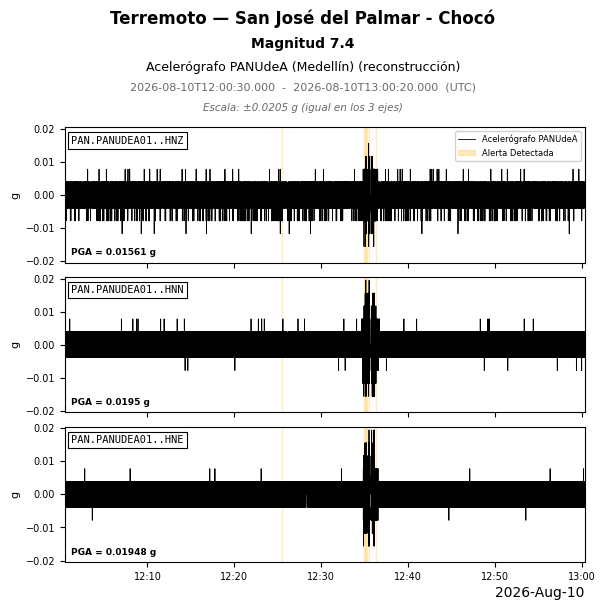

  guardado: output\terremoto_choco\acelerometro\acelerometro_hora_completa_g_{UTC,LOCAL}.png
  animación: output\terremoto_choco\acelerometro\acelerometro_hora_completa_g_{UTC,LOCAL}.gif


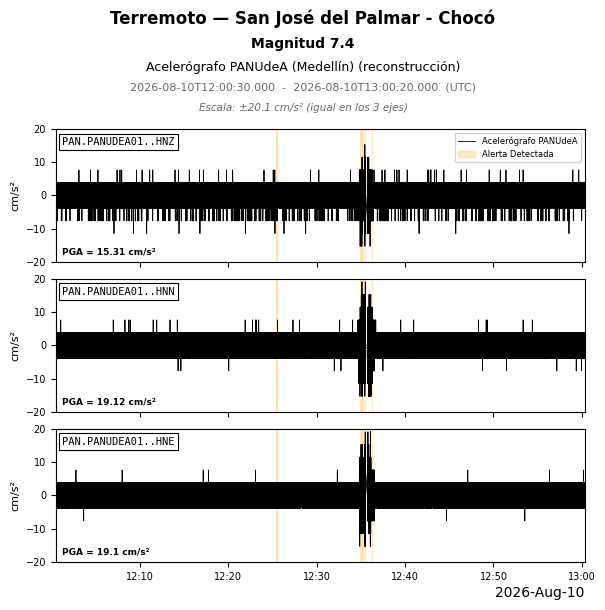

  guardado: output\terremoto_choco\acelerometro\acelerometro_hora_completa_cms2_{UTC,LOCAL}.png
  animación: output\terremoto_choco\acelerometro\acelerometro_hora_completa_cms2_{UTC,LOCAL}.gif
--- ventana registro_sgc: 2026-08-10T12:25:26.520000 -> 2026-08-10T12:45:04.190000 UTC


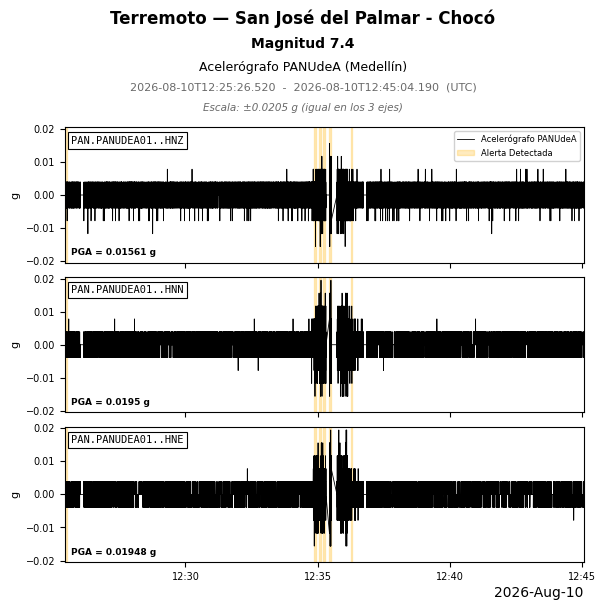

  guardado: output\terremoto_choco\registro_sgc\acelerometro\acelerometro_registro_sgc_g_{UTC,LOCAL}.png
  animación: output\terremoto_choco\registro_sgc\acelerometro\acelerometro_registro_sgc_g_{UTC,LOCAL}.gif


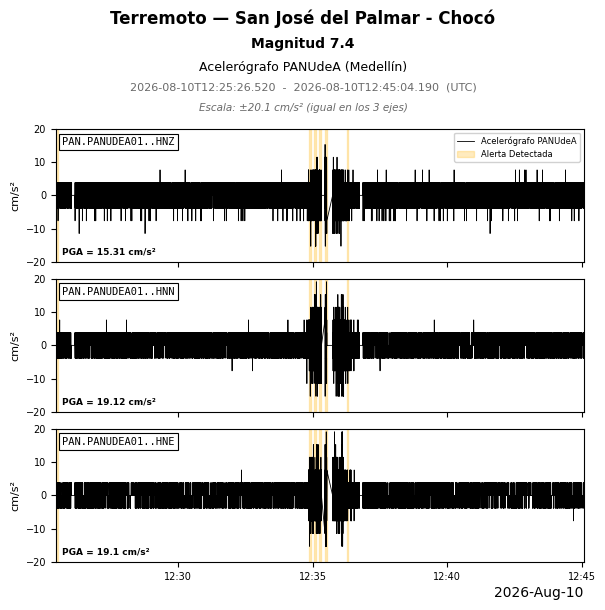

  guardado: output\terremoto_choco\registro_sgc\acelerometro\acelerometro_registro_sgc_cms2_{UTC,LOCAL}.png
  animación: output\terremoto_choco\registro_sgc\acelerometro\acelerometro_registro_sgc_cms2_{UTC,LOCAL}.gif
--- ventana desde_primera_alerta: 2026-08-10T12:25:27.000000 -> 2026-08-10T12:45:04.190000 UTC


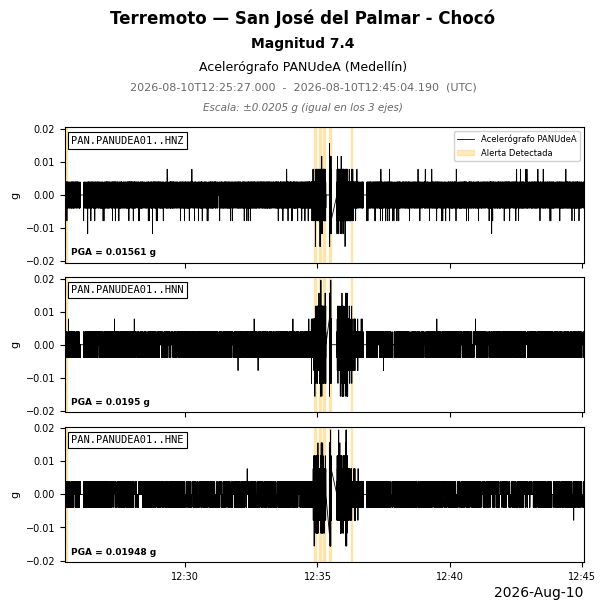

  guardado: output\terremoto_choco\desde_primera_alerta\acelerometro\acelerometro_desde_primera_alerta_g_{UTC,LOCAL}.png
  animación: output\terremoto_choco\desde_primera_alerta\acelerometro\acelerometro_desde_primera_alerta_g_{UTC,LOCAL}.gif


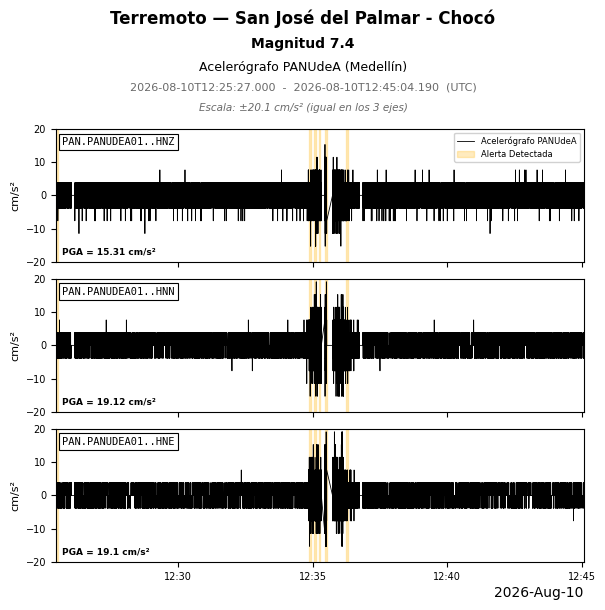

  guardado: output\terremoto_choco\desde_primera_alerta\acelerometro\acelerometro_desde_primera_alerta_cms2_{UTC,LOCAL}.png
  animación: output\terremoto_choco\desde_primera_alerta\acelerometro\acelerometro_desde_primera_alerta_cms2_{UTC,LOCAL}.gif


In [13]:
_texto_acel = f"{ACELEROMETRO['nombre']} (reconstrucción)"
for u in UNIDADES:
    base = DIR_SALIDA / "acelerometro" / f"acelerometro_hora_completa_{_SUFIJO_UNIDAD[u]}.png"
    s = serie_acelerometro(u)
    plot_sgc_style(s, _ETIQUETA_UNIDAD[u], base, estaciones=_texto_acel, alert_windows=RECON["alert_windows"])
    if GENERAR_ANIMACIONES:
        crear_animacion_sgc_style(s, _ETIQUETA_UNIDAD[u], base, estaciones=_texto_acel, alert_windows=RECON["alert_windows"])

for v in VENTANAS:
    nombre_v = nombre_ventana(v)
    try:
        t0, t1 = resolver_ventana(v, RECON, ESTACIONES, ORIGEN_EVENTO)
    except ValueError as e:
        PROBLEMAS.append(f"acelerómetro, ventana {nombre_v}: {e}")
        print(f"[AVISO] {e}")
        continue
    print(f"--- ventana {nombre_v}: {t0} -> {t1} UTC")
    for u in UNIDADES:
        base = DIR_SALIDA / nombre_v / "acelerometro" / f"acelerometro_{nombre_v}_{_SUFIJO_UNIDAD[u]}.png"
        s = serie_acelerometro(u, t0, t1)
        plot_sgc_style(s, _ETIQUETA_UNIDAD[u], base, estaciones=ACELEROMETRO["nombre"], alert_windows=RECON["alert_windows"])
        if GENERAR_ANIMACIONES:
            crear_animacion_sgc_style(s, _ETIQUETA_UNIDAD[u], base, estaciones=ACELEROMETRO["nombre"], alert_windows=RECON["alert_windows"])

## §15 — Comparación acelerómetro UdeA vs. cada estación

Por cada ventana y estación: el acelerómetro solo (`propia`), la estación sola (`sgc`) y ambos superpuestos
(`junta`, UdeA en negro y SGC en rojo) en cada unidad, más la animación de la `junta`. Estaciones sin
calibrar: la estación en cuentas y la `junta` normalizada (σ).

=== Ventana: registro_sgc ===
Riosucio: 2026-08-10T12:25:25.355000 -> 2026-08-10T12:45:04.190000 UTC


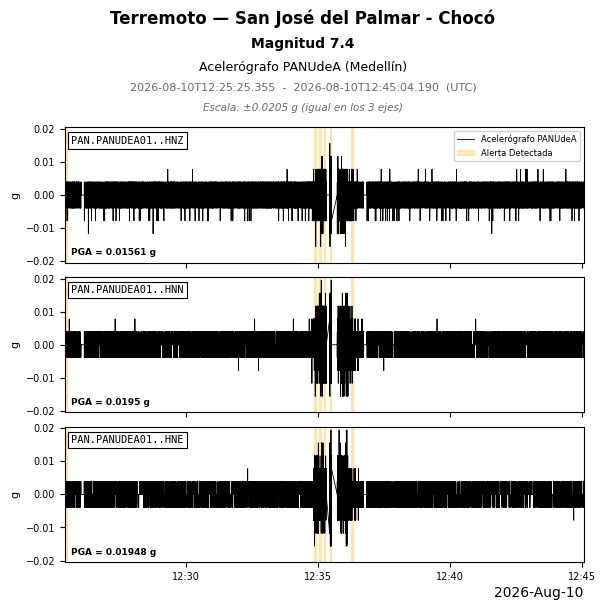

  guardado: output\terremoto_choco\registro_sgc\Riosucio\riosucio_RIO2C_10_propia_g_{UTC,LOCAL}.png


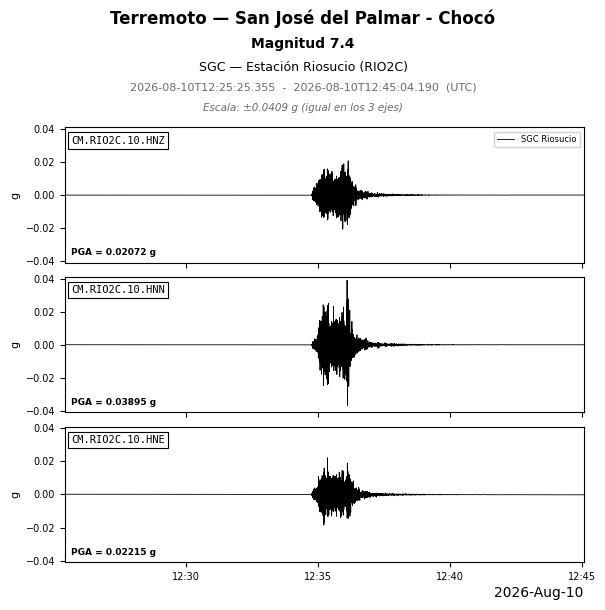

  guardado: output\terremoto_choco\registro_sgc\Riosucio\riosucio_RIO2C_10_sgc_g_{UTC,LOCAL}.png


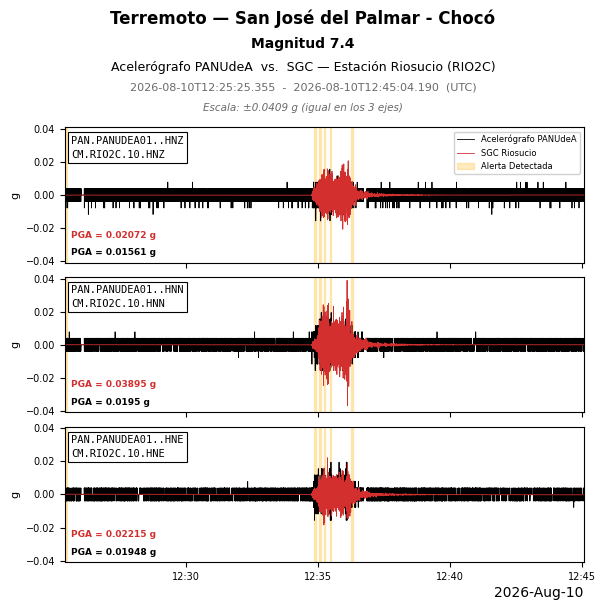

  guardado: output\terremoto_choco\registro_sgc\Riosucio\riosucio_RIO2C_10_junta_g_{UTC,LOCAL}.png
  animación: output\terremoto_choco\registro_sgc\Riosucio\riosucio_RIO2C_10_junta_g_{UTC,LOCAL}.gif


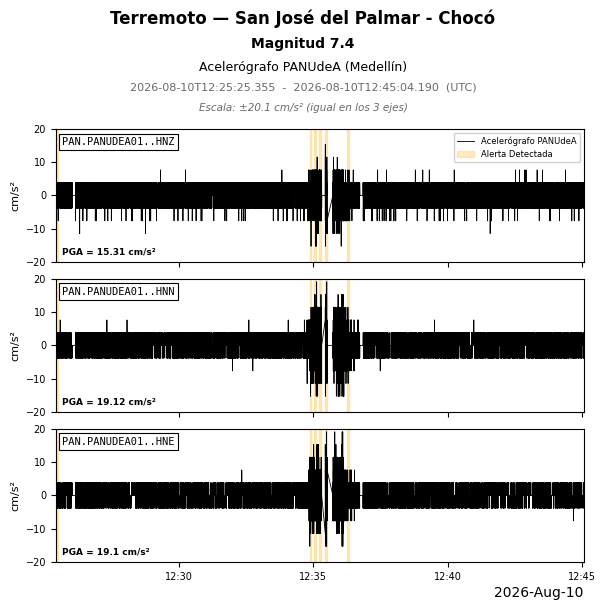

  guardado: output\terremoto_choco\registro_sgc\Riosucio\riosucio_RIO2C_10_propia_cms2_{UTC,LOCAL}.png


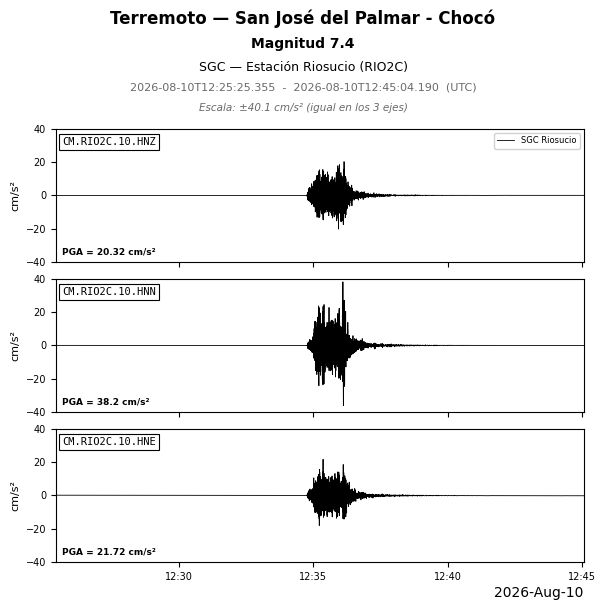

  guardado: output\terremoto_choco\registro_sgc\Riosucio\riosucio_RIO2C_10_sgc_cms2_{UTC,LOCAL}.png


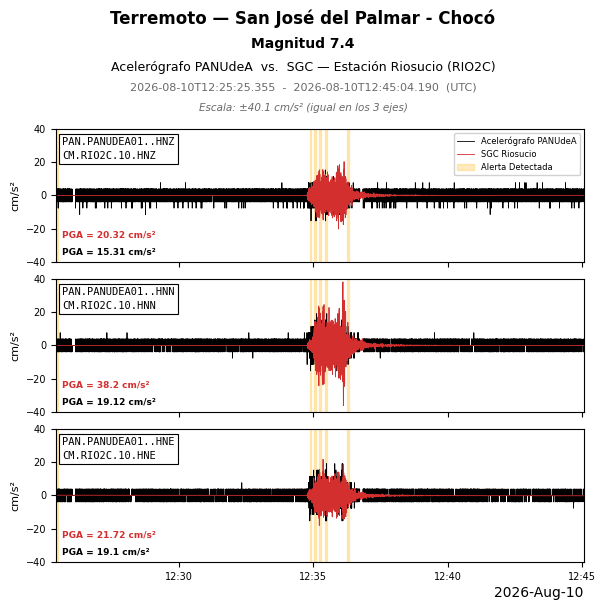

  guardado: output\terremoto_choco\registro_sgc\Riosucio\riosucio_RIO2C_10_junta_cms2_{UTC,LOCAL}.png
  animación: output\terremoto_choco\registro_sgc\Riosucio\riosucio_RIO2C_10_junta_cms2_{UTC,LOCAL}.gif
Pereira: 2026-08-10T12:25:25.660000 -> 2026-08-10T12:45:04.790000 UTC


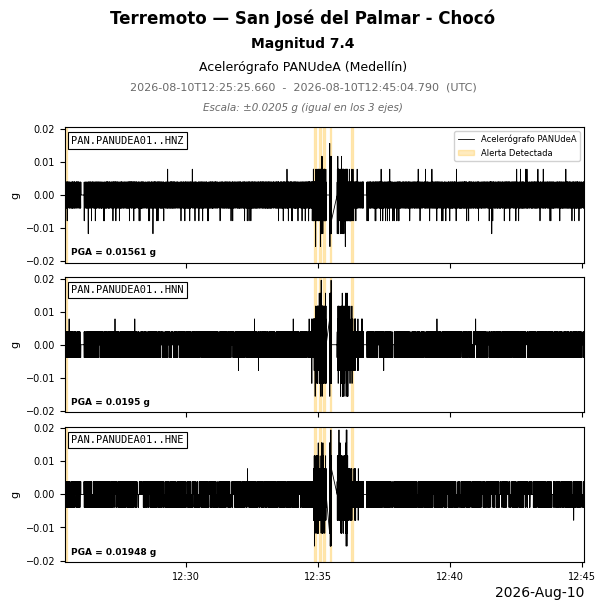

  guardado: output\terremoto_choco\registro_sgc\Pereira\pereira_CBOCA_10_propia_g_{UTC,LOCAL}.png


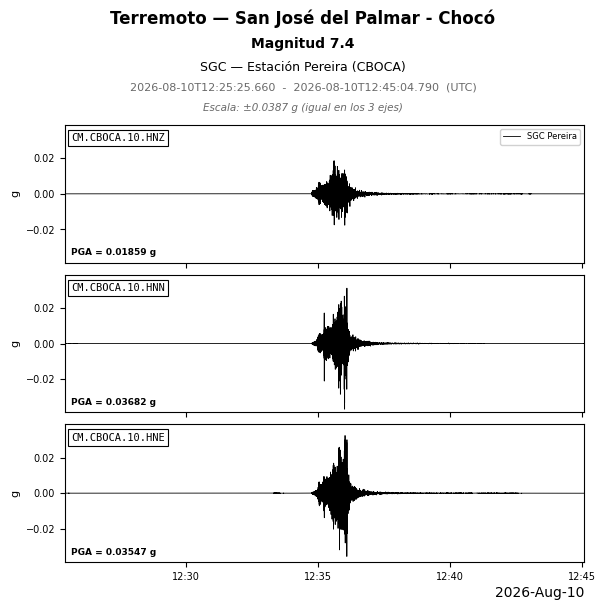

  guardado: output\terremoto_choco\registro_sgc\Pereira\pereira_CBOCA_10_sgc_g_{UTC,LOCAL}.png


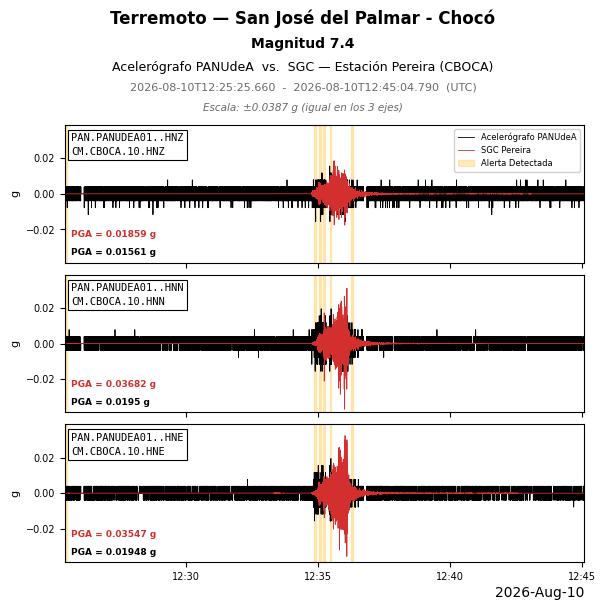

  guardado: output\terremoto_choco\registro_sgc\Pereira\pereira_CBOCA_10_junta_g_{UTC,LOCAL}.png
  animación: output\terremoto_choco\registro_sgc\Pereira\pereira_CBOCA_10_junta_g_{UTC,LOCAL}.gif


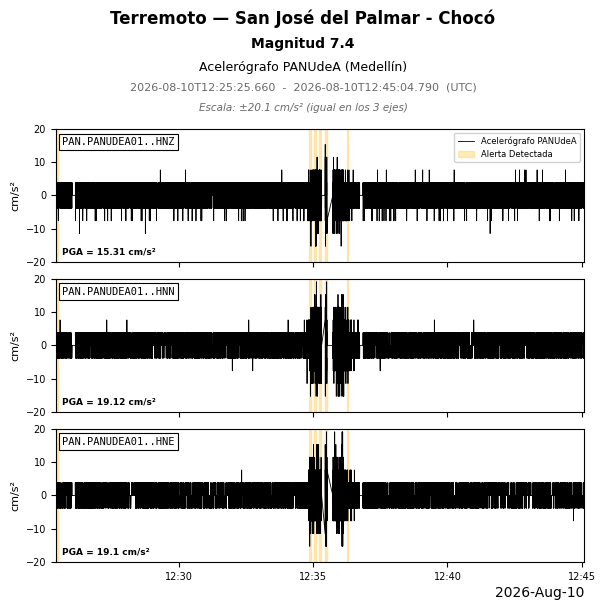

  guardado: output\terremoto_choco\registro_sgc\Pereira\pereira_CBOCA_10_propia_cms2_{UTC,LOCAL}.png


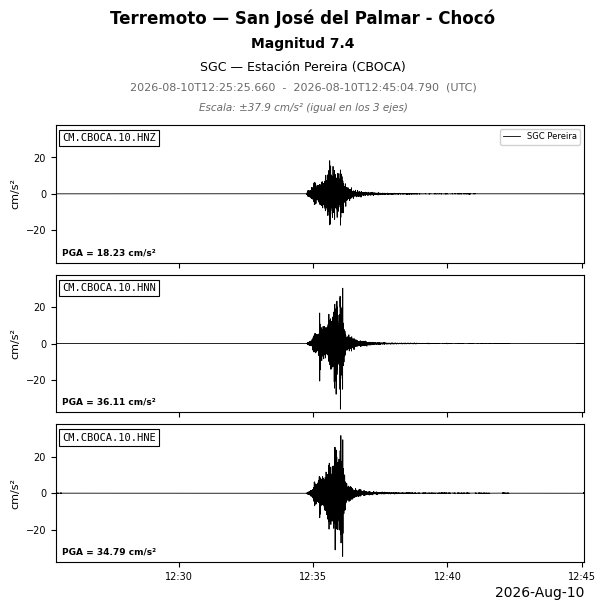

  guardado: output\terremoto_choco\registro_sgc\Pereira\pereira_CBOCA_10_sgc_cms2_{UTC,LOCAL}.png


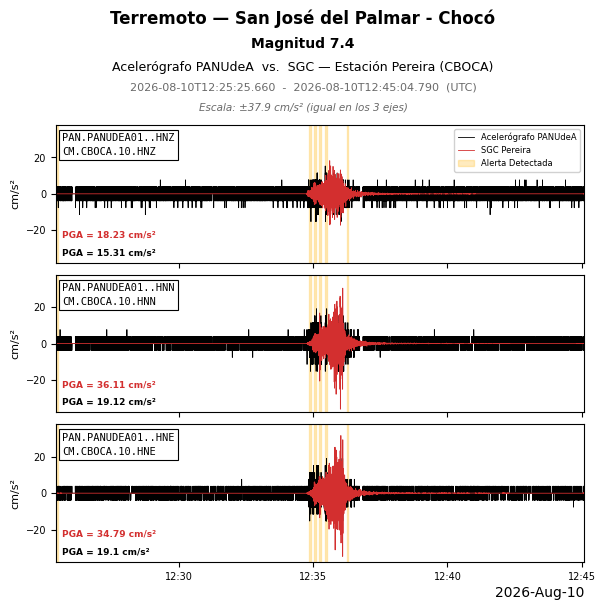

  guardado: output\terremoto_choco\registro_sgc\Pereira\pereira_CBOCA_10_junta_cms2_{UTC,LOCAL}.png
  animación: output\terremoto_choco\registro_sgc\Pereira\pereira_CBOCA_10_junta_cms2_{UTC,LOCAL}.gif
Dabeiba: 2026-08-10T12:25:26.520000 -> 2026-08-10T12:45:05.685000 UTC


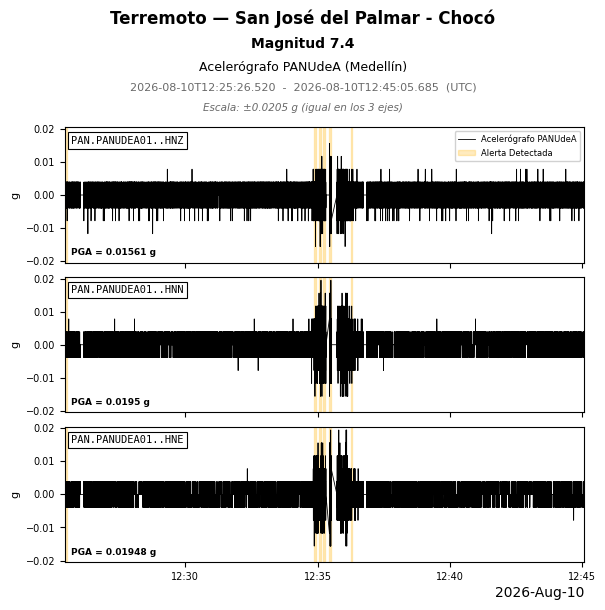

  guardado: output\terremoto_choco\registro_sgc\Dabeiba\dabeiba_DBB_10_propia_g_{UTC,LOCAL}.png


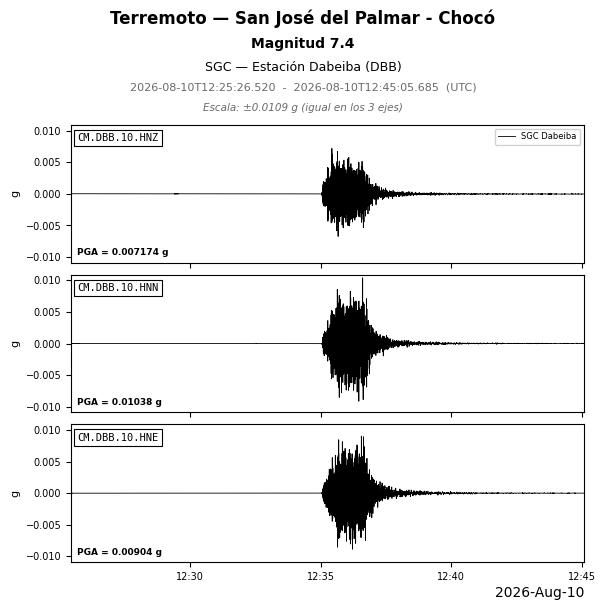

  guardado: output\terremoto_choco\registro_sgc\Dabeiba\dabeiba_DBB_10_sgc_g_{UTC,LOCAL}.png


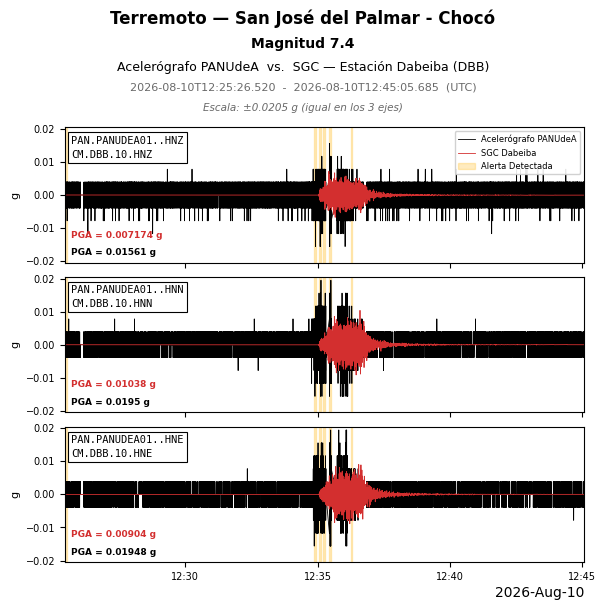

  guardado: output\terremoto_choco\registro_sgc\Dabeiba\dabeiba_DBB_10_junta_g_{UTC,LOCAL}.png
  animación: output\terremoto_choco\registro_sgc\Dabeiba\dabeiba_DBB_10_junta_g_{UTC,LOCAL}.gif


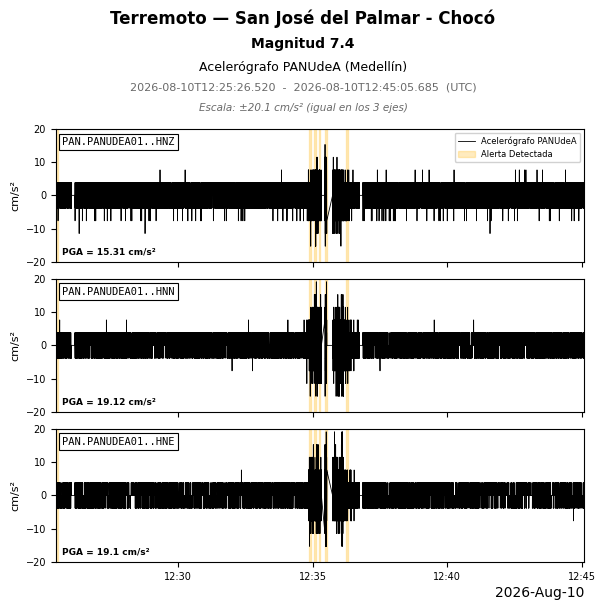

  guardado: output\terremoto_choco\registro_sgc\Dabeiba\dabeiba_DBB_10_propia_cms2_{UTC,LOCAL}.png


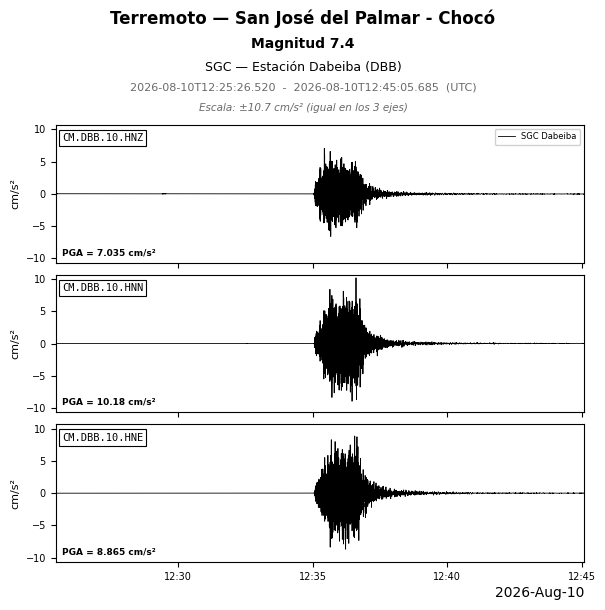

  guardado: output\terremoto_choco\registro_sgc\Dabeiba\dabeiba_DBB_10_sgc_cms2_{UTC,LOCAL}.png


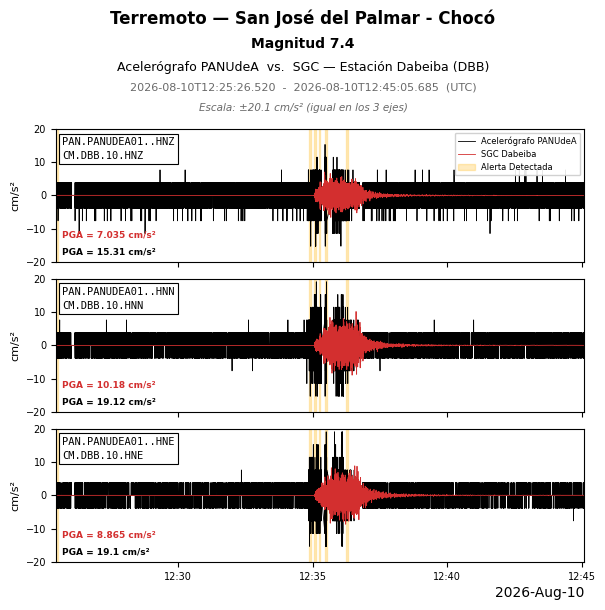

  guardado: output\terremoto_choco\registro_sgc\Dabeiba\dabeiba_DBB_10_junta_cms2_{UTC,LOCAL}.png
  animación: output\terremoto_choco\registro_sgc\Dabeiba\dabeiba_DBB_10_junta_cms2_{UTC,LOCAL}.gif
=== Ventana: desde_primera_alerta ===
Riosucio: 2026-08-10T12:25:27.000000 -> 2026-08-10T12:45:04.190000 UTC


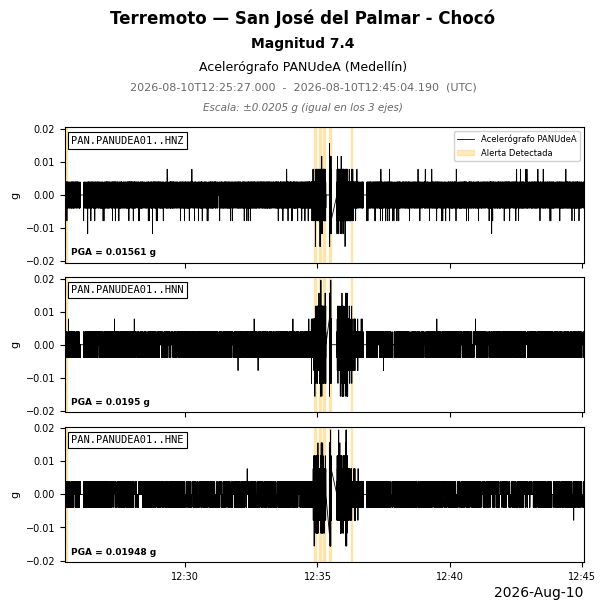

  guardado: output\terremoto_choco\desde_primera_alerta\Riosucio\riosucio_RIO2C_10_propia_g_{UTC,LOCAL}.png


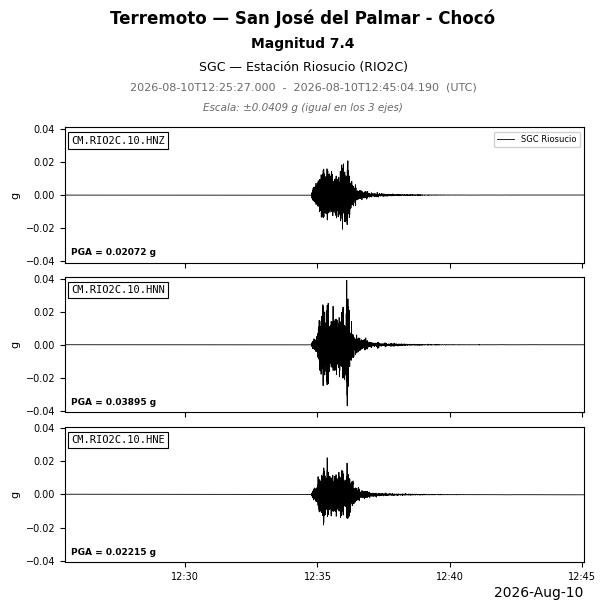

  guardado: output\terremoto_choco\desde_primera_alerta\Riosucio\riosucio_RIO2C_10_sgc_g_{UTC,LOCAL}.png


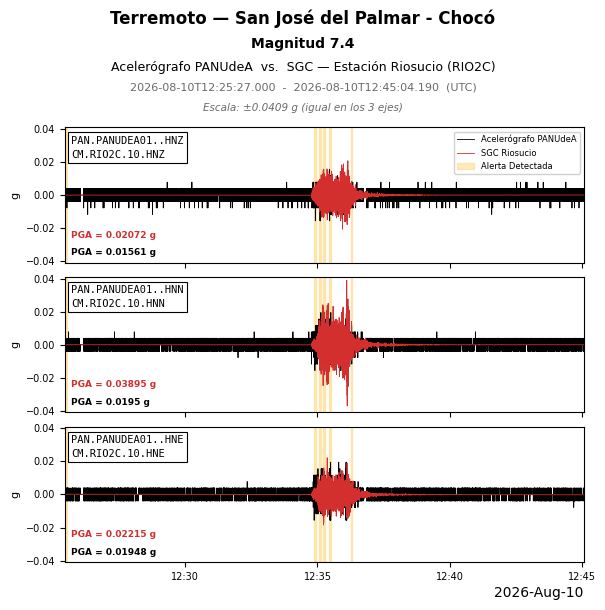

  guardado: output\terremoto_choco\desde_primera_alerta\Riosucio\riosucio_RIO2C_10_junta_g_{UTC,LOCAL}.png
  animación: output\terremoto_choco\desde_primera_alerta\Riosucio\riosucio_RIO2C_10_junta_g_{UTC,LOCAL}.gif


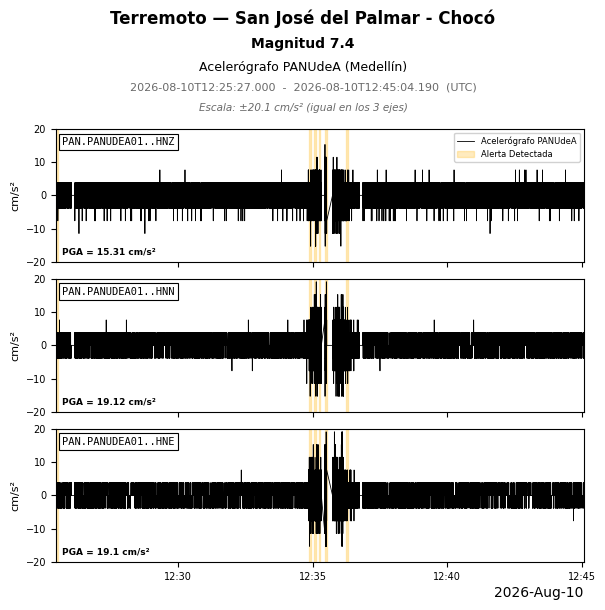

  guardado: output\terremoto_choco\desde_primera_alerta\Riosucio\riosucio_RIO2C_10_propia_cms2_{UTC,LOCAL}.png


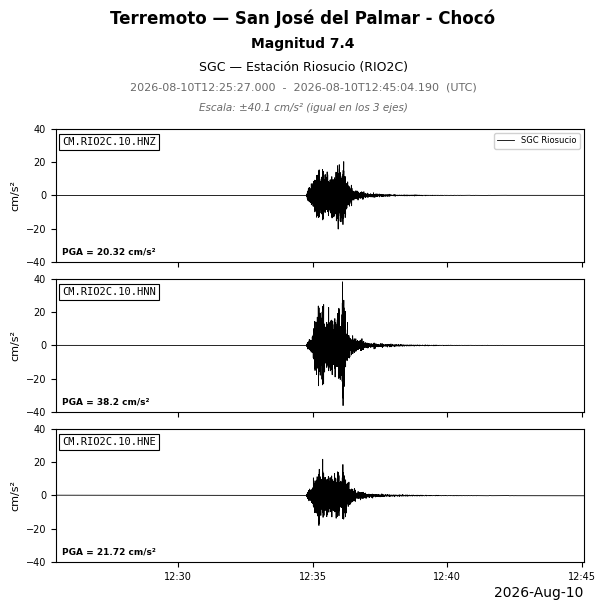

  guardado: output\terremoto_choco\desde_primera_alerta\Riosucio\riosucio_RIO2C_10_sgc_cms2_{UTC,LOCAL}.png


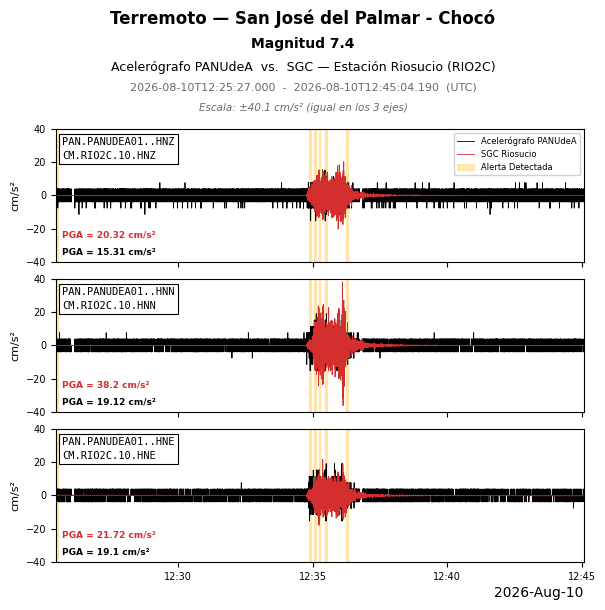

  guardado: output\terremoto_choco\desde_primera_alerta\Riosucio\riosucio_RIO2C_10_junta_cms2_{UTC,LOCAL}.png
  animación: output\terremoto_choco\desde_primera_alerta\Riosucio\riosucio_RIO2C_10_junta_cms2_{UTC,LOCAL}.gif
Pereira: 2026-08-10T12:25:27.000000 -> 2026-08-10T12:45:04.790000 UTC


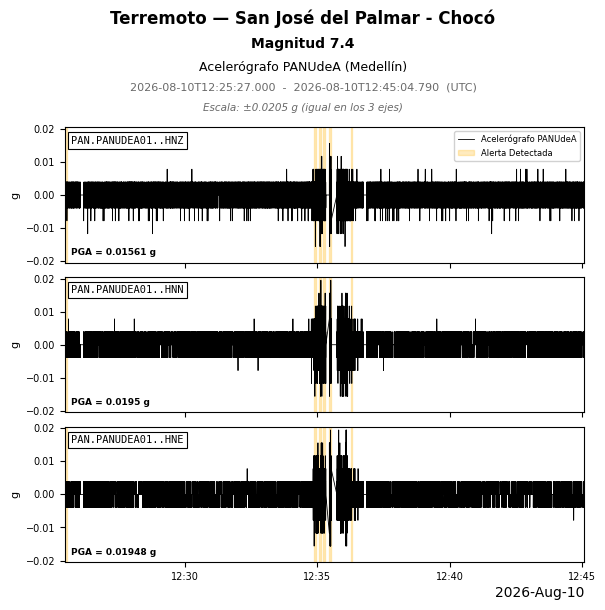

  guardado: output\terremoto_choco\desde_primera_alerta\Pereira\pereira_CBOCA_10_propia_g_{UTC,LOCAL}.png


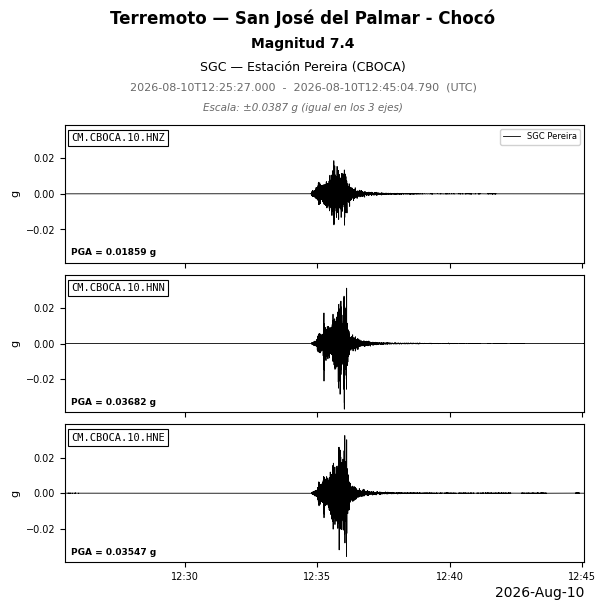

  guardado: output\terremoto_choco\desde_primera_alerta\Pereira\pereira_CBOCA_10_sgc_g_{UTC,LOCAL}.png


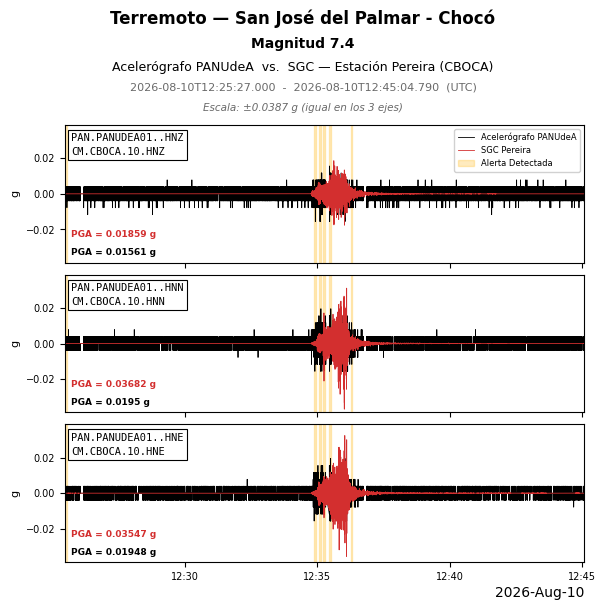

  guardado: output\terremoto_choco\desde_primera_alerta\Pereira\pereira_CBOCA_10_junta_g_{UTC,LOCAL}.png
  animación: output\terremoto_choco\desde_primera_alerta\Pereira\pereira_CBOCA_10_junta_g_{UTC,LOCAL}.gif


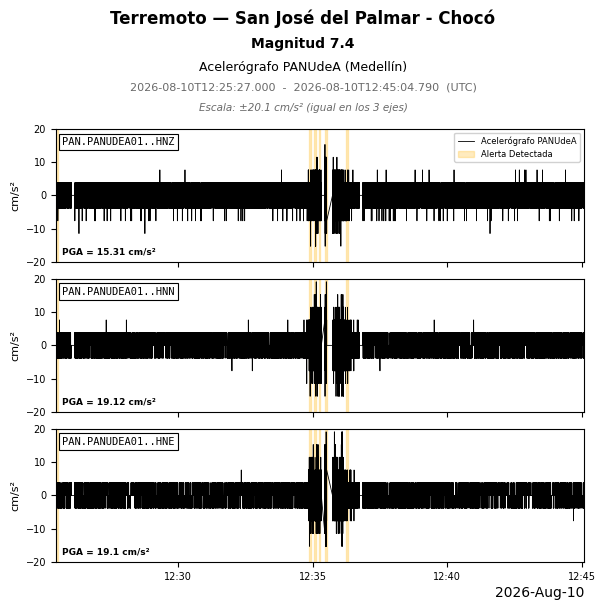

  guardado: output\terremoto_choco\desde_primera_alerta\Pereira\pereira_CBOCA_10_propia_cms2_{UTC,LOCAL}.png


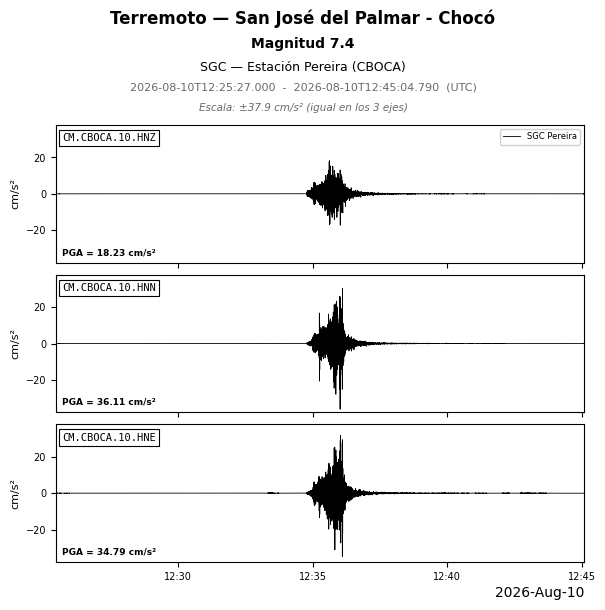

  guardado: output\terremoto_choco\desde_primera_alerta\Pereira\pereira_CBOCA_10_sgc_cms2_{UTC,LOCAL}.png


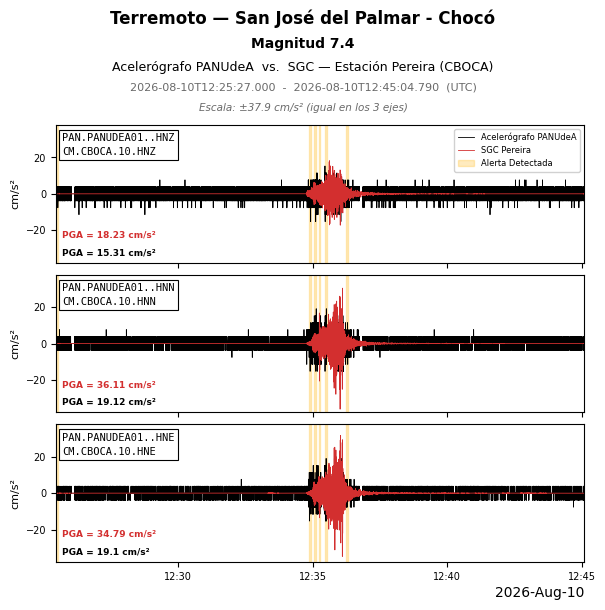

  guardado: output\terremoto_choco\desde_primera_alerta\Pereira\pereira_CBOCA_10_junta_cms2_{UTC,LOCAL}.png
  animación: output\terremoto_choco\desde_primera_alerta\Pereira\pereira_CBOCA_10_junta_cms2_{UTC,LOCAL}.gif
Dabeiba: 2026-08-10T12:25:27.000000 -> 2026-08-10T12:45:05.685000 UTC


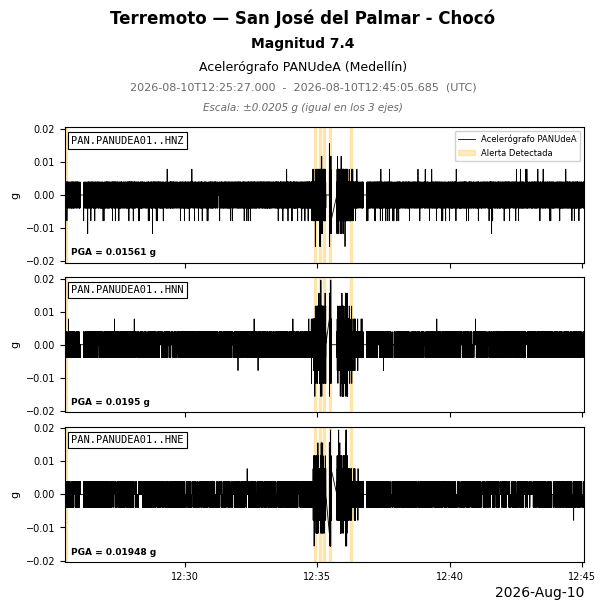

  guardado: output\terremoto_choco\desde_primera_alerta\Dabeiba\dabeiba_DBB_10_propia_g_{UTC,LOCAL}.png


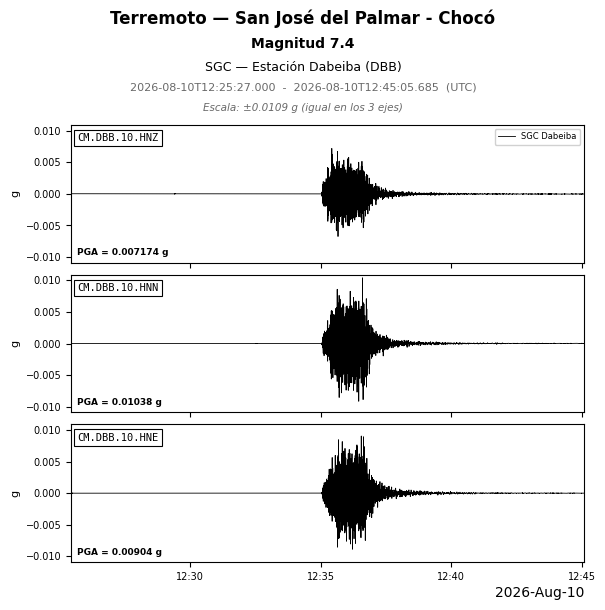

  guardado: output\terremoto_choco\desde_primera_alerta\Dabeiba\dabeiba_DBB_10_sgc_g_{UTC,LOCAL}.png


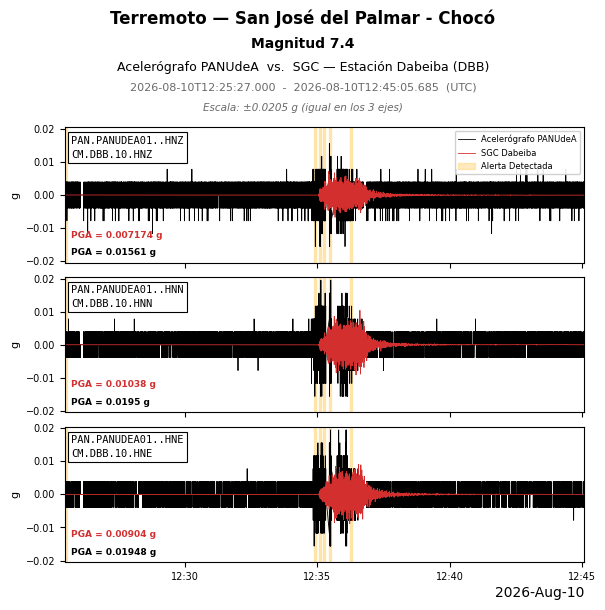

  guardado: output\terremoto_choco\desde_primera_alerta\Dabeiba\dabeiba_DBB_10_junta_g_{UTC,LOCAL}.png
  animación: output\terremoto_choco\desde_primera_alerta\Dabeiba\dabeiba_DBB_10_junta_g_{UTC,LOCAL}.gif


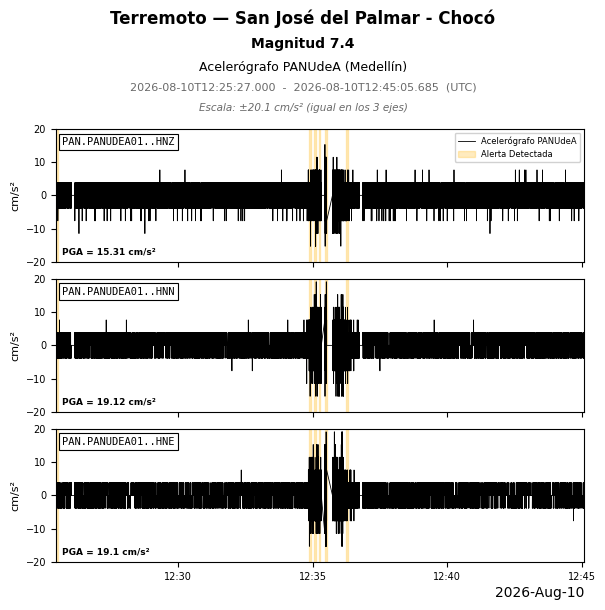

  guardado: output\terremoto_choco\desde_primera_alerta\Dabeiba\dabeiba_DBB_10_propia_cms2_{UTC,LOCAL}.png


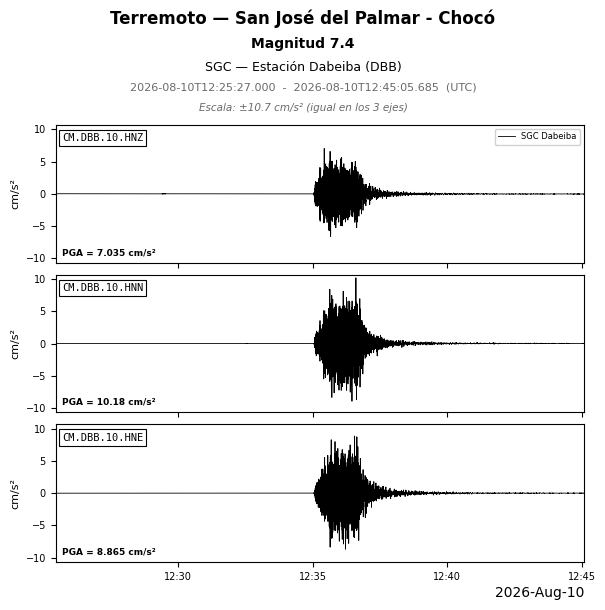

  guardado: output\terremoto_choco\desde_primera_alerta\Dabeiba\dabeiba_DBB_10_sgc_cms2_{UTC,LOCAL}.png


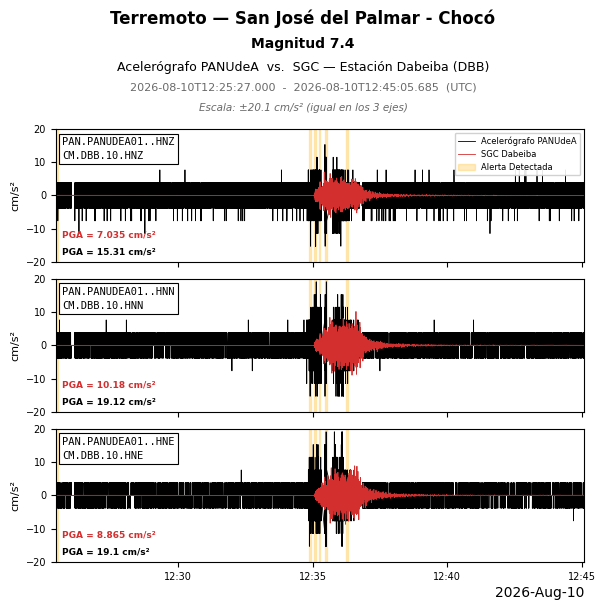

  guardado: output\terremoto_choco\desde_primera_alerta\Dabeiba\dabeiba_DBB_10_junta_cms2_{UTC,LOCAL}.png
  animación: output\terremoto_choco\desde_primera_alerta\Dabeiba\dabeiba_DBB_10_junta_cms2_{UTC,LOCAL}.gif


In [14]:
for v in VENTANAS:
    nombre_v = nombre_ventana(v)
    print(f"=== Ventana: {nombre_v} ===")
    for est in ESTACIONES:
        try:
            t0, t1 = resolver_ventana(v, RECON, [est], ORIGEN_EVENTO)
        except ValueError as e:
            PROBLEMAS.append(f"{est['nombre']}, ventana {nombre_v}: {e}")
            print(f"[AVISO] {est['nombre']}: {e}")
            continue
        print(f"{est['nombre']}: {t0} -> {t1} UTC")
        carpeta = DIR_SALIDA / nombre_v / est["nombre"]
        texto_est   = f"SGC — Estación {est['nombre']} ({est['codigo']})"
        texto_ambas = f"{ACELEROMETRO['leyenda']}  vs.  {texto_est}"
        alertas = RECON["alert_windows"]

        for u in UNIDADES:
            etq, suf = _ETIQUETA_UNIDAD[u], _SUFIJO_UNIDAD[u]
            s_acel = serie_acelerometro(u, t0, t1)
            plot_sgc_style(s_acel, etq, carpeta / f"{est['slug']}_propia_{suf}.png",
                           estaciones=ACELEROMETRO["nombre"], alert_windows=alertas)
            if est["calibrada"]:
                plot_sgc_style(serie_estacion(est, u, t0=t0, t1=t1), etq, carpeta / f"{est['slug']}_sgc_{suf}.png",
                               estaciones=texto_est)
                junta = _combinar(s_acel, serie_estacion(est, u, color=COLOR_SGC, t0=t0, t1=t1))
                plot_sgc_style(junta, etq, carpeta / f"{est['slug']}_junta_{suf}.png",
                               estaciones=texto_ambas, alert_windows=alertas)
                if GENERAR_ANIMACIONES:
                    crear_animacion_sgc_style(junta, etq, carpeta / f"{est['slug']}_junta_{suf}.png",
                                              estaciones=texto_ambas, alert_windows=alertas)

        if not est["calibrada"]:
            plot_sgc_style(serie_estacion(est, "cuentas", t0=t0, t1=t1), _ETIQUETA_UNIDAD["cuentas"],
                           carpeta / f"{est['slug']}_sgc_cuentas.png", estaciones=texto_est + " sin calibrar")
            junta = _combinar(serie_acelerometro("σ", t0, t1), serie_estacion(est, "σ", color=COLOR_SGC, t0=t0, t1=t1))
            plot_sgc_style(junta, _ETIQUETA_UNIDAD["σ"], carpeta / f"{est['slug']}_junta_norm.png",
                           estaciones=texto_ambas + " (normalizado)", alert_windows=alertas)
            if GENERAR_ANIMACIONES:
                crear_animacion_sgc_style(junta, _ETIQUETA_UNIDAD["σ"], carpeta / f"{est['slug']}_junta_norm.png",
                                          estaciones=texto_ambas + " (normalizado)", alert_windows=alertas)

## §16 — Estaciones juntas

Cada grupo de `GRUPOS_ESTACIONES` en cada ventana, con `juntar_estaciones()` (§11): UdeA al fondo y las
estaciones del grupo encima, en su orden y color.

=== todas (Riosucio, Pereira y Dabeiba) — ventana registro_sgc ===


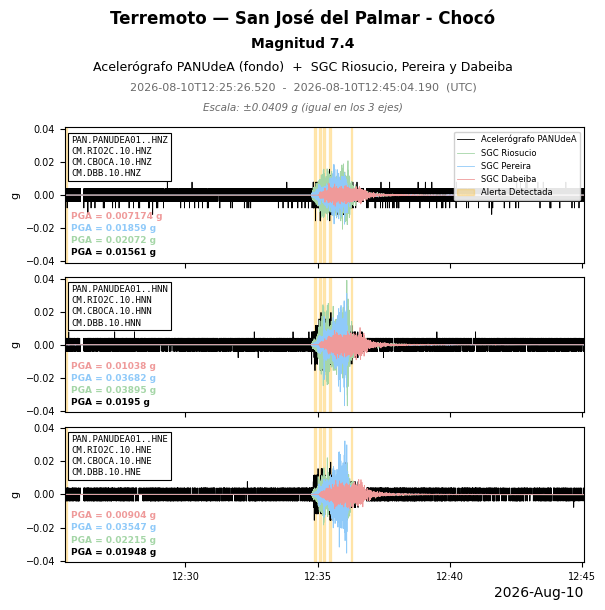

  guardado: output\terremoto_choco\registro_sgc\juntas_todas\juntas_todas_g_{UTC,LOCAL}.png
  animación: output\terremoto_choco\registro_sgc\juntas_todas\juntas_todas_g_{UTC,LOCAL}.gif


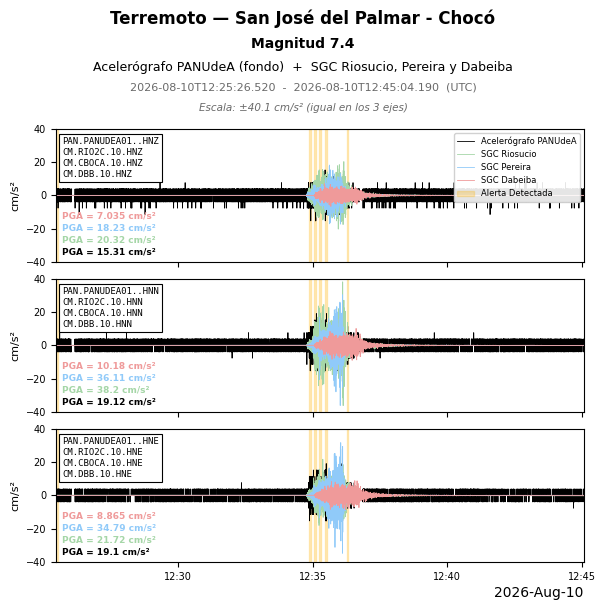

  guardado: output\terremoto_choco\registro_sgc\juntas_todas\juntas_todas_cms2_{UTC,LOCAL}.png
  animación: output\terremoto_choco\registro_sgc\juntas_todas\juntas_todas_cms2_{UTC,LOCAL}.gif
=== todas (Riosucio, Pereira y Dabeiba) — ventana desde_primera_alerta ===


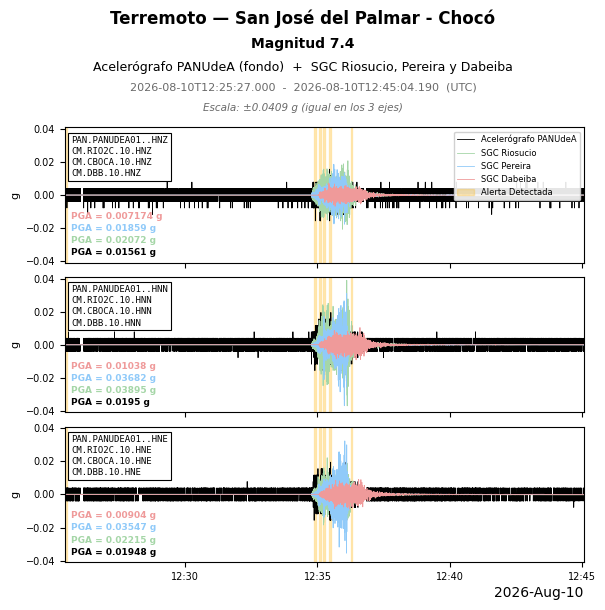

  guardado: output\terremoto_choco\desde_primera_alerta\juntas_todas\juntas_todas_g_{UTC,LOCAL}.png
  animación: output\terremoto_choco\desde_primera_alerta\juntas_todas\juntas_todas_g_{UTC,LOCAL}.gif


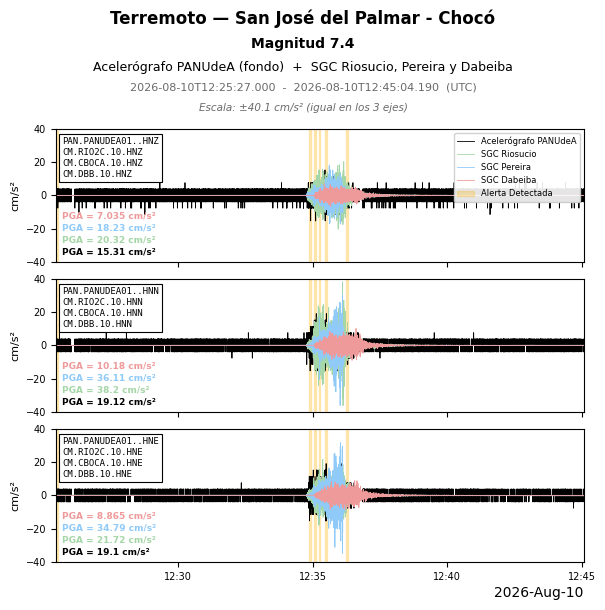

  guardado: output\terremoto_choco\desde_primera_alerta\juntas_todas\juntas_todas_cms2_{UTC,LOCAL}.png
  animación: output\terremoto_choco\desde_primera_alerta\juntas_todas\juntas_todas_cms2_{UTC,LOCAL}.gif


In [15]:
_cargadas = {e["nombre"].lower() for e in ESTACIONES} | {e["codigo"].lower() for e in ESTACIONES}
for v in VENTANAS:
    for grupo, nombres in GRUPOS_ESTACIONES.items():
        disponibles = [n for n in nombres if n.lower() in _cargadas]
        faltan = [n for n in nombres if n.lower() not in _cargadas]
        if faltan:
            PROBLEMAS.append(f"grupo {grupo}: {faltan} no se cargaron, se grafica sin ellas")
        if not disponibles:
            continue
        print(f"=== {grupo} ({unir_nombres(disponibles)}) — ventana {nombre_ventana(v)} ===")
        try:
            juntar_estaciones(disponibles, v, nombre_grupo=grupo)
        except ValueError as e:
            PROBLEMAS.append(f"grupo {grupo}, ventana {nombre_ventana(v)}: {e}")
            print(f"[AVISO] {e}")

**Ejemplo para armar un grupo a mano** (descomentar y ejecutar): cualquier combinación de estaciones, en el
orden de dibujo que se quiera, en cualquier ventana.

In [16]:
# juntar_estaciones(["Pereira", "Dabeiba"],
#                   {"nombre": "sismo", "modo": "relativa_origen", "antes_s": 30, "despues_s": 240},
#                   nombre_grupo="pereira_dabeiba")

## §17 — Resumen

PGA de cada componente (Z, N, E) por ventana y estación, avisos acumulados y archivos generados.

In [17]:
def _pga(t, datos, t0, t1):
    _, d = recortar(t, datos, t0, t1)
    return np.nanmax(np.abs(d), axis=0) if len(d) else np.full(datos.shape[1], np.nan)


_orden = [LABELS.index(c) for c in ORDEN_FILAS]
_canales = "/".join(CANAL_POR_COMP[c] for c in ORDEN_FILAS)
for v in VENTANAS:
    nombre_v = nombre_ventana(v)
    print(f"\nVentana {nombre_v} -- PGA {_canales}")
    print(f"  {'Estación':<10} {'PGA estación SGC':<38} {'PGA UdeA (misma ventana)':<30} Fuente")
    for est in ESTACIONES:
        try:
            t0, t1 = resolver_ventana(v, RECON, [est], ORIGEN_EVENTO)
        except ValueError:
            continue
        p_sgc = _pga(est["t_utc"], est["datos"], t0, t1)[_orden]
        p_acel = _pga(RECON["t_utc"], RECON["data_g"] * G_TO_CMS2, t0, t1)[_orden]
        sgc_txt = " / ".join(f"{p:.4g}" for p in p_sgc) + f" {est['unidad']}"
        acel_txt = " / ".join(f"{p:.4g}" for p in p_acel) + " cm/s²"
        print(f"  {est['nombre']:<10} {sgc_txt:<38} {acel_txt:<30} {est['fuente']}")

print("\nAvisos:" if PROBLEMAS else "\nSin avisos.")
for p in PROBLEMAS:
    print(f"  - {p}")

print(f"\nArchivos generados en {DIR_SALIDA}:")
_total_png = _total_gif = 0
for carpeta in sorted({p.parent for p in DIR_SALIDA.rglob("*") if p.is_file()}):
    n_png, n_gif = len(list(carpeta.glob("*.png"))), len(list(carpeta.glob("*.gif")))
    _total_png, _total_gif = _total_png + n_png, _total_gif + n_gif
    print(f"  {str(carpeta.relative_to(DIR_SALIDA)):<45} {n_png:3d} PNG  {n_gif:3d} GIF")
print(f"  {'TOTAL':<45} {_total_png:3d} PNG  {_total_gif:3d} GIF")


Ventana registro_sgc -- PGA Z/N/E
  Estación   PGA estación SGC                       PGA UdeA (misma ventana)       Fuente
  Riosucio   20.32 / 38.2 / 21.72 cm/s²             15.31 / 19.12 / 19.1 cm/s²     .mseed calibrado con .anc
  Pereira    18.23 / 36.11 / 34.79 cm/s²            15.31 / 19.12 / 19.1 cm/s²     .mseed calibrado con .anc
  Dabeiba    7.035 / 10.18 / 8.865 cm/s²            15.31 / 19.12 / 19.1 cm/s²     .mseed calibrado con .anc

Ventana desde_primera_alerta -- PGA Z/N/E
  Estación   PGA estación SGC                       PGA UdeA (misma ventana)       Fuente
  Riosucio   20.32 / 38.2 / 21.72 cm/s²             15.31 / 19.12 / 19.1 cm/s²     .mseed calibrado con .anc
  Pereira    18.23 / 36.11 / 34.79 cm/s²            15.31 / 19.12 / 19.1 cm/s²     .mseed calibrado con .anc
  Dabeiba    7.035 / 10.18 / 8.865 cm/s²            15.31 / 19.12 / 19.1 cm/s²     .mseed calibrado con .anc

Sin avisos.

Archivos generados en output\terremoto_choco:
  acelerometro              